In [1]:
import pandas as pd
from scripts.aux_msa_functions import *
from scipy.spatial.distance import cdist, pdist, squareform
import os
import numpy as np
import torch
from Bio import Phylo
import seaborn as sns
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
import re
from scipy.stats import pearsonr
from math import floor,ceil
from scipy import stats
import esm
from patsy import dmatrices
import statsmodels.api as sm

torch.set_grad_enabled(False)

In [2]:
pfam_metadata = pd.read_csv("./data/pfam-metadata/pfam_metadata.tsv", delimiter = "\t")

all_metrics_dataframe = pd.read_csv("./untracked-files/sequence_scores_table.tsv", delimiter = "\t")
# all_metrics_dataframe = all_metrics_dataframe.merge(pfam_metadata, left_on = "family", right_on="pfam_id")



### Attention and Sequence-level Scores


KeyboardInterrupt



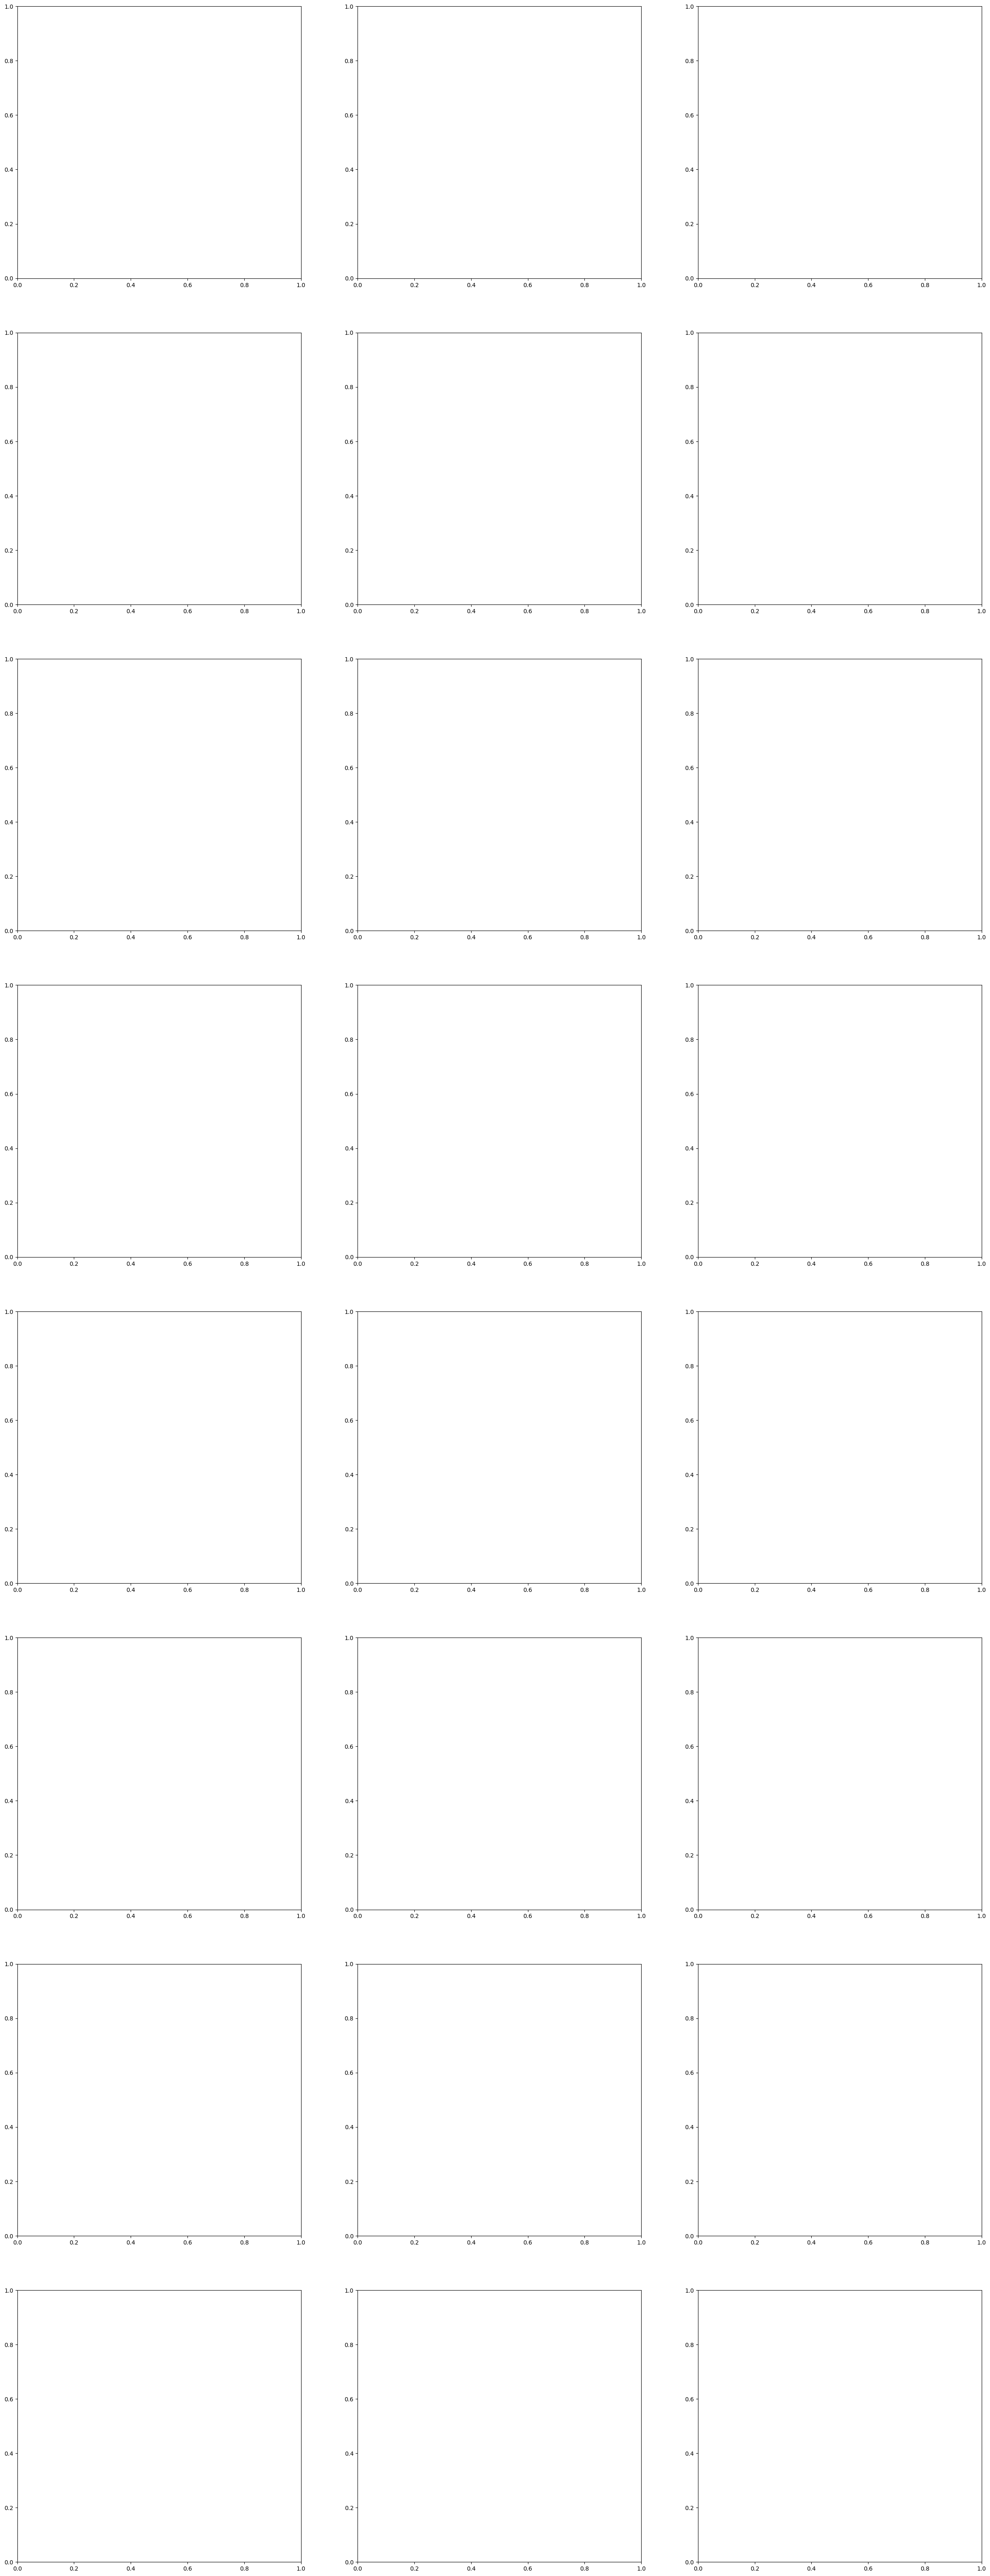

In [3]:
family = "PF00004"
sim_ind = 1
tool = "MSA-1b-logitsprop-static-10-init-seq-0"

families = list(all_metrics_dataframe["family"].unique())
sim_inds = list(range(1,11))

device = "cuda:1"

model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
batch_converter = alphabet.get_batch_converter()
model = model.to(device)
model.eval() 

ncols = 3
nrows = max(2,int(ceil((len(families))/3)))

fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize = (30,10 * nrows))

corr_matrix_hmmer_list = []
corr_matrix_stat_list = []
corr_matrix_plddt_list = []
corr_matrix_nat_dist_list = []
corr_matrix_self_dist_list = []
corr_matrix_rmsd_list = []

all_families_df = pd.DataFrame()

for k, family in enumerate(families):

    torch.cuda.empty_cache()

    all_metrics_dataframe_fam = all_metrics_dataframe.loc[(all_metrics_dataframe["pfam_id"] == family) & 
                                                      (all_metrics_dataframe["sim_ind"] == sim_ind) &
                                                      (all_metrics_dataframe["tool"] == tool), :].reset_index(drop = True)

    i = floor(k/3)
    j = k % 3


    if len(all_metrics_dataframe_fam) > 500:
        # random_ind = list(np.random.choice(range(len(all_metrics_dataframe_fam)),500, replace = False))
        all_metrics_dataframe_fam = all_metrics_dataframe_fam.iloc[:500, :].reset_index(drop = True)

    sequences = [(name, seq) for name, seq in zip(all_metrics_dataframe_fam["sequence_name"], all_metrics_dataframe_fam["sequence"])]
    device = "cuda:1" if torch.cuda.is_available() else "cpu"

    _,_, sequences_tensor = batch_converter([sequences])
    sequences_tensor = sequences_tensor.to(device)

    model_output = model(sequences_tensor, need_head_weights=True)
    column_attns = model_output["col_attentions"][0]

    n_seqs = len(sequences)
    mean_attn = torch.mean(column_attns, axis = [3])

    del model_output, sequences_tensor, column_attns
    torch.cuda.empty_cache()

    mean_attn = torch.mean(mean_attn, axis = [2]).cpu().numpy()
    mean_attn = np.reshape(mean_attn, newshape = (-1,n_seqs), order = 'C')
    mean_attn = np.transpose(mean_attn)

    mean_attn_df = pd.DataFrame(mean_attn, columns = [f"col_attn_{i}" for i in range(mean_attn.shape[1])])
    final_df = pd.concat([mean_attn_df, all_metrics_dataframe_fam], axis = 1)

    all_families_df = pd.concat([all_families_df, final_df]).reset_index(drop = True)

    corr_matrix_hmmer = np.zeros(144)
    corr_matrix_stat = np.zeros(144)
    corr_matrix_plddt = np.zeros(144)
    corr_matrix_nat_dist = np.zeros(144)
    corr_matrix_self_dist = np.zeros(144)
    corr_matrix_rmsd = np.zeros(144)

    for a in range(len(corr_matrix_hmmer)):

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["hmmer_seq_score"]).statistic
        corr_matrix_hmmer[a] = corr

        try:
            corr = pearsonr(final_df[f"col_attn_{a}"], final_df["stat_energy_scores"]).statistic
            corr_matrix_stat[a] = corr
        except:
            pass

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["plddt_scores"]).statistic
        corr_matrix_plddt[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["min_natural_ham_dist_seed"]).statistic
        corr_matrix_nat_dist[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["max_self_ham_distance"]).statistic
        corr_matrix_self_dist[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["rmsd"]).statistic
        corr_matrix_rmsd[a] = corr

    corr_matrix_hmmer = np.reshape(corr_matrix_hmmer, newshape = (12,12), order = "C")
    corr_matrix_stat = np.reshape(corr_matrix_stat, newshape = (12,12), order = "C")
    corr_matrix_plddt = np.reshape(corr_matrix_plddt, newshape = (12,12), order = "C")
    corr_matrix_nat_dist = np.reshape(corr_matrix_nat_dist, newshape = (12,12), order = "C")
    corr_matrix_self_dist = np.reshape(corr_matrix_self_dist, newshape = (12,12), order = "C")
    corr_matrix_rmsd = np.reshape(corr_matrix_rmsd, newshape = (12,12), order = "C")

    corr_matrix_hmmer_list.append(corr_matrix_hmmer)
    corr_matrix_stat_list.append(corr_matrix_stat)
    corr_matrix_plddt_list.append(corr_matrix_plddt)
    corr_matrix_nat_dist_list.append(corr_matrix_nat_dist)
    corr_matrix_self_dist_list.append(corr_matrix_self_dist)
    corr_matrix_rmsd_list.append(corr_matrix_rmsd)

    im = axes[i][j].imshow(corr_matrix_hmmer, vmin = -1, vmax = 1, cmap = "RdBu_r")
    plt.colorbar(im, ax=axes[i][j])
    axes[i][j].set_title(f"{family}")


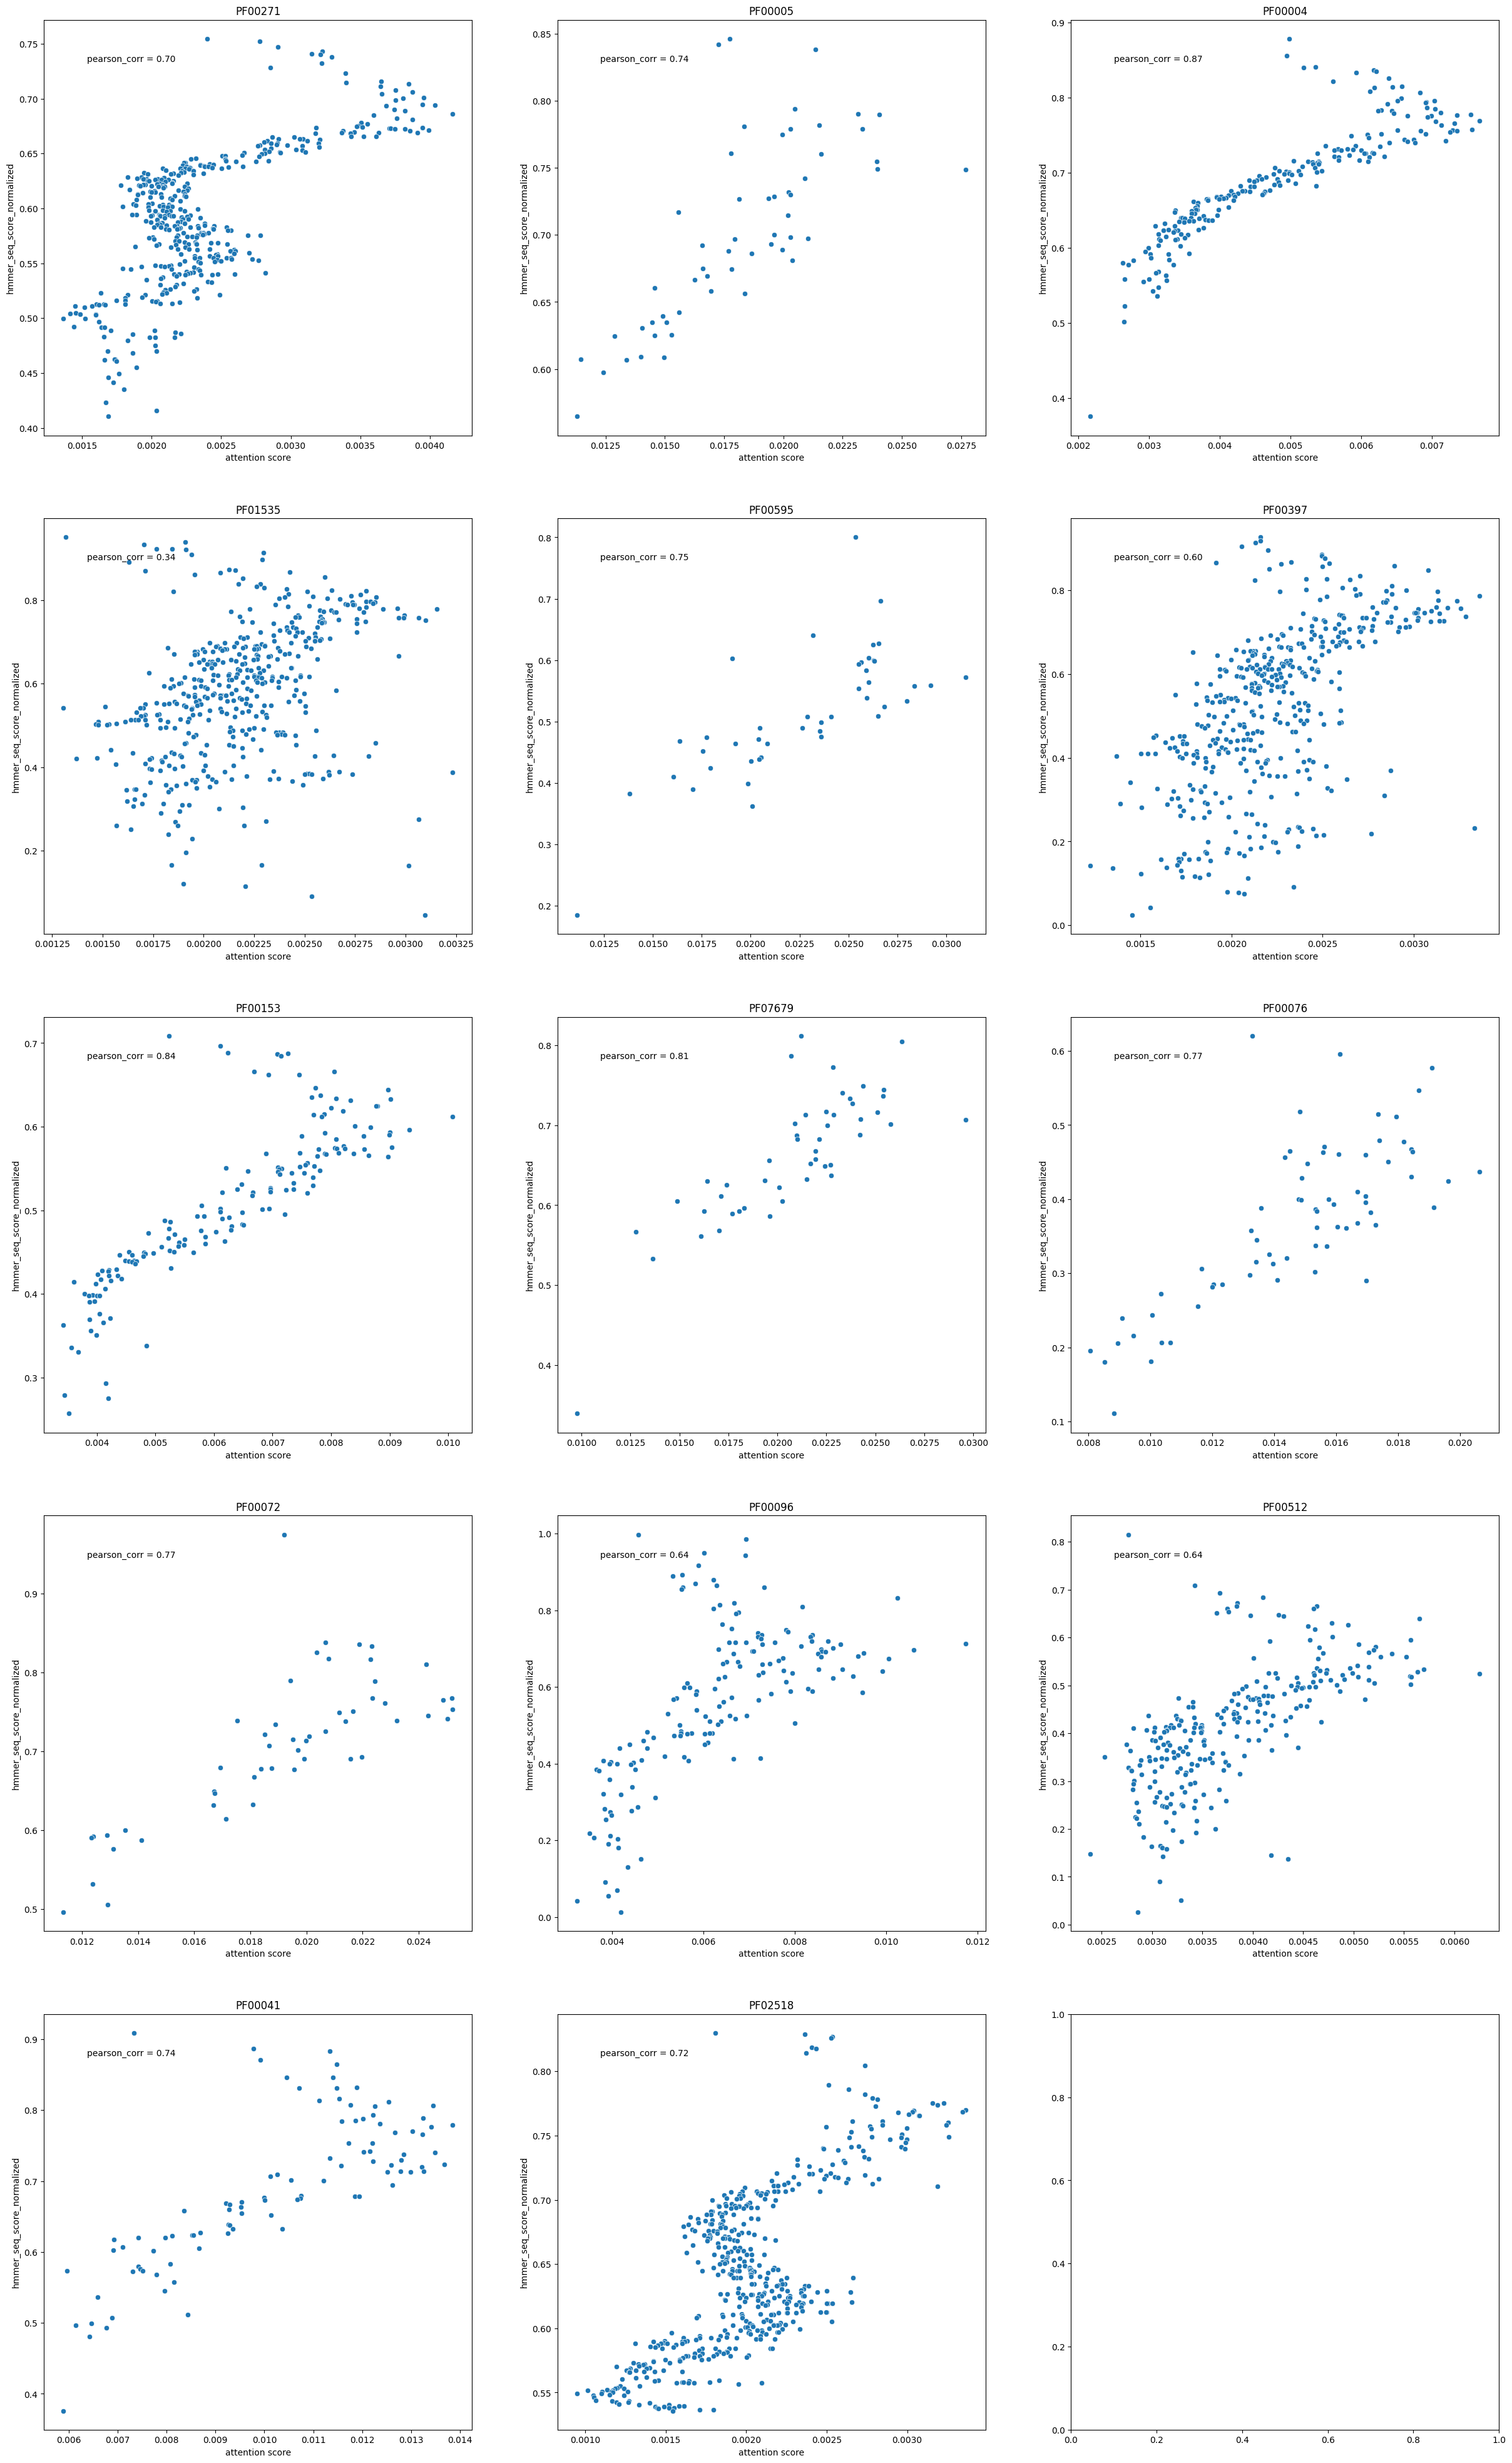

In [ ]:

head_number = 1
score = "hmmer_seq_score_normalized"

families = all_families_df["pfam_id"].unique()

ncols = 3
nrows = max(2,int(ceil((len(families))/3)))

fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize = (30,10 * nrows))

for k, fam in enumerate(families):

    i = floor(k/3)
    j = k % 3
    
    all_families_df_fam = all_families_df.loc[all_families_df["family"] == fam, :].reset_index(drop = True)
    sns.scatterplot(data = all_families_df_fam, x = f"col_attn_{head_number}", y = score, ax = axes[i][j])
    axes[i][j].set_title(families[k])
    axes[i][j].set_xlabel("attention score")
    axes[i][j].set_ylabel(score)
    pearson_corr = pearsonr(all_families_df_fam[f"col_attn_{head_number}"], all_families_df_fam[score])
    axes[i][j].annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.1,0.9), xycoords = "axes fraction", fontsize = 10)



plt.savefig(f"attn_head_{head_number}_vs_{score}.png")
# all_families_df_fam = all_families_df.loc[all_families_df["family"] == fam, :].reset_index(drop = True)

# pearson_corr = pearsonr(x =all_families_df_fam[f"col_attn_{head_number}"], y=all_families_df_fam[score])
# plt.annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.1,0.9), xycoords = "axes fraction", fontsize = 10)

In [ ]:
mean_hmmer_corr = np.stack(corr_matrix_hmmer_list).mean(axis=0)
mean_stat_corr = np.stack(corr_matrix_stat_list).mean(axis=0)
mean_plddt_corr = np.stack(corr_matrix_plddt_list).mean(axis=0)
mean_nat_dist_corr = np.stack(corr_matrix_nat_dist_list).mean(axis=0)
mean_self_dist_corr = np.stack(corr_matrix_self_dist_list).mean(axis=0)
mean_rmsd_corr = np.stack(corr_matrix_rmsd_list).mean(axis=0)

Text(0.5, 1.0, 'mean_rmsd_corr')

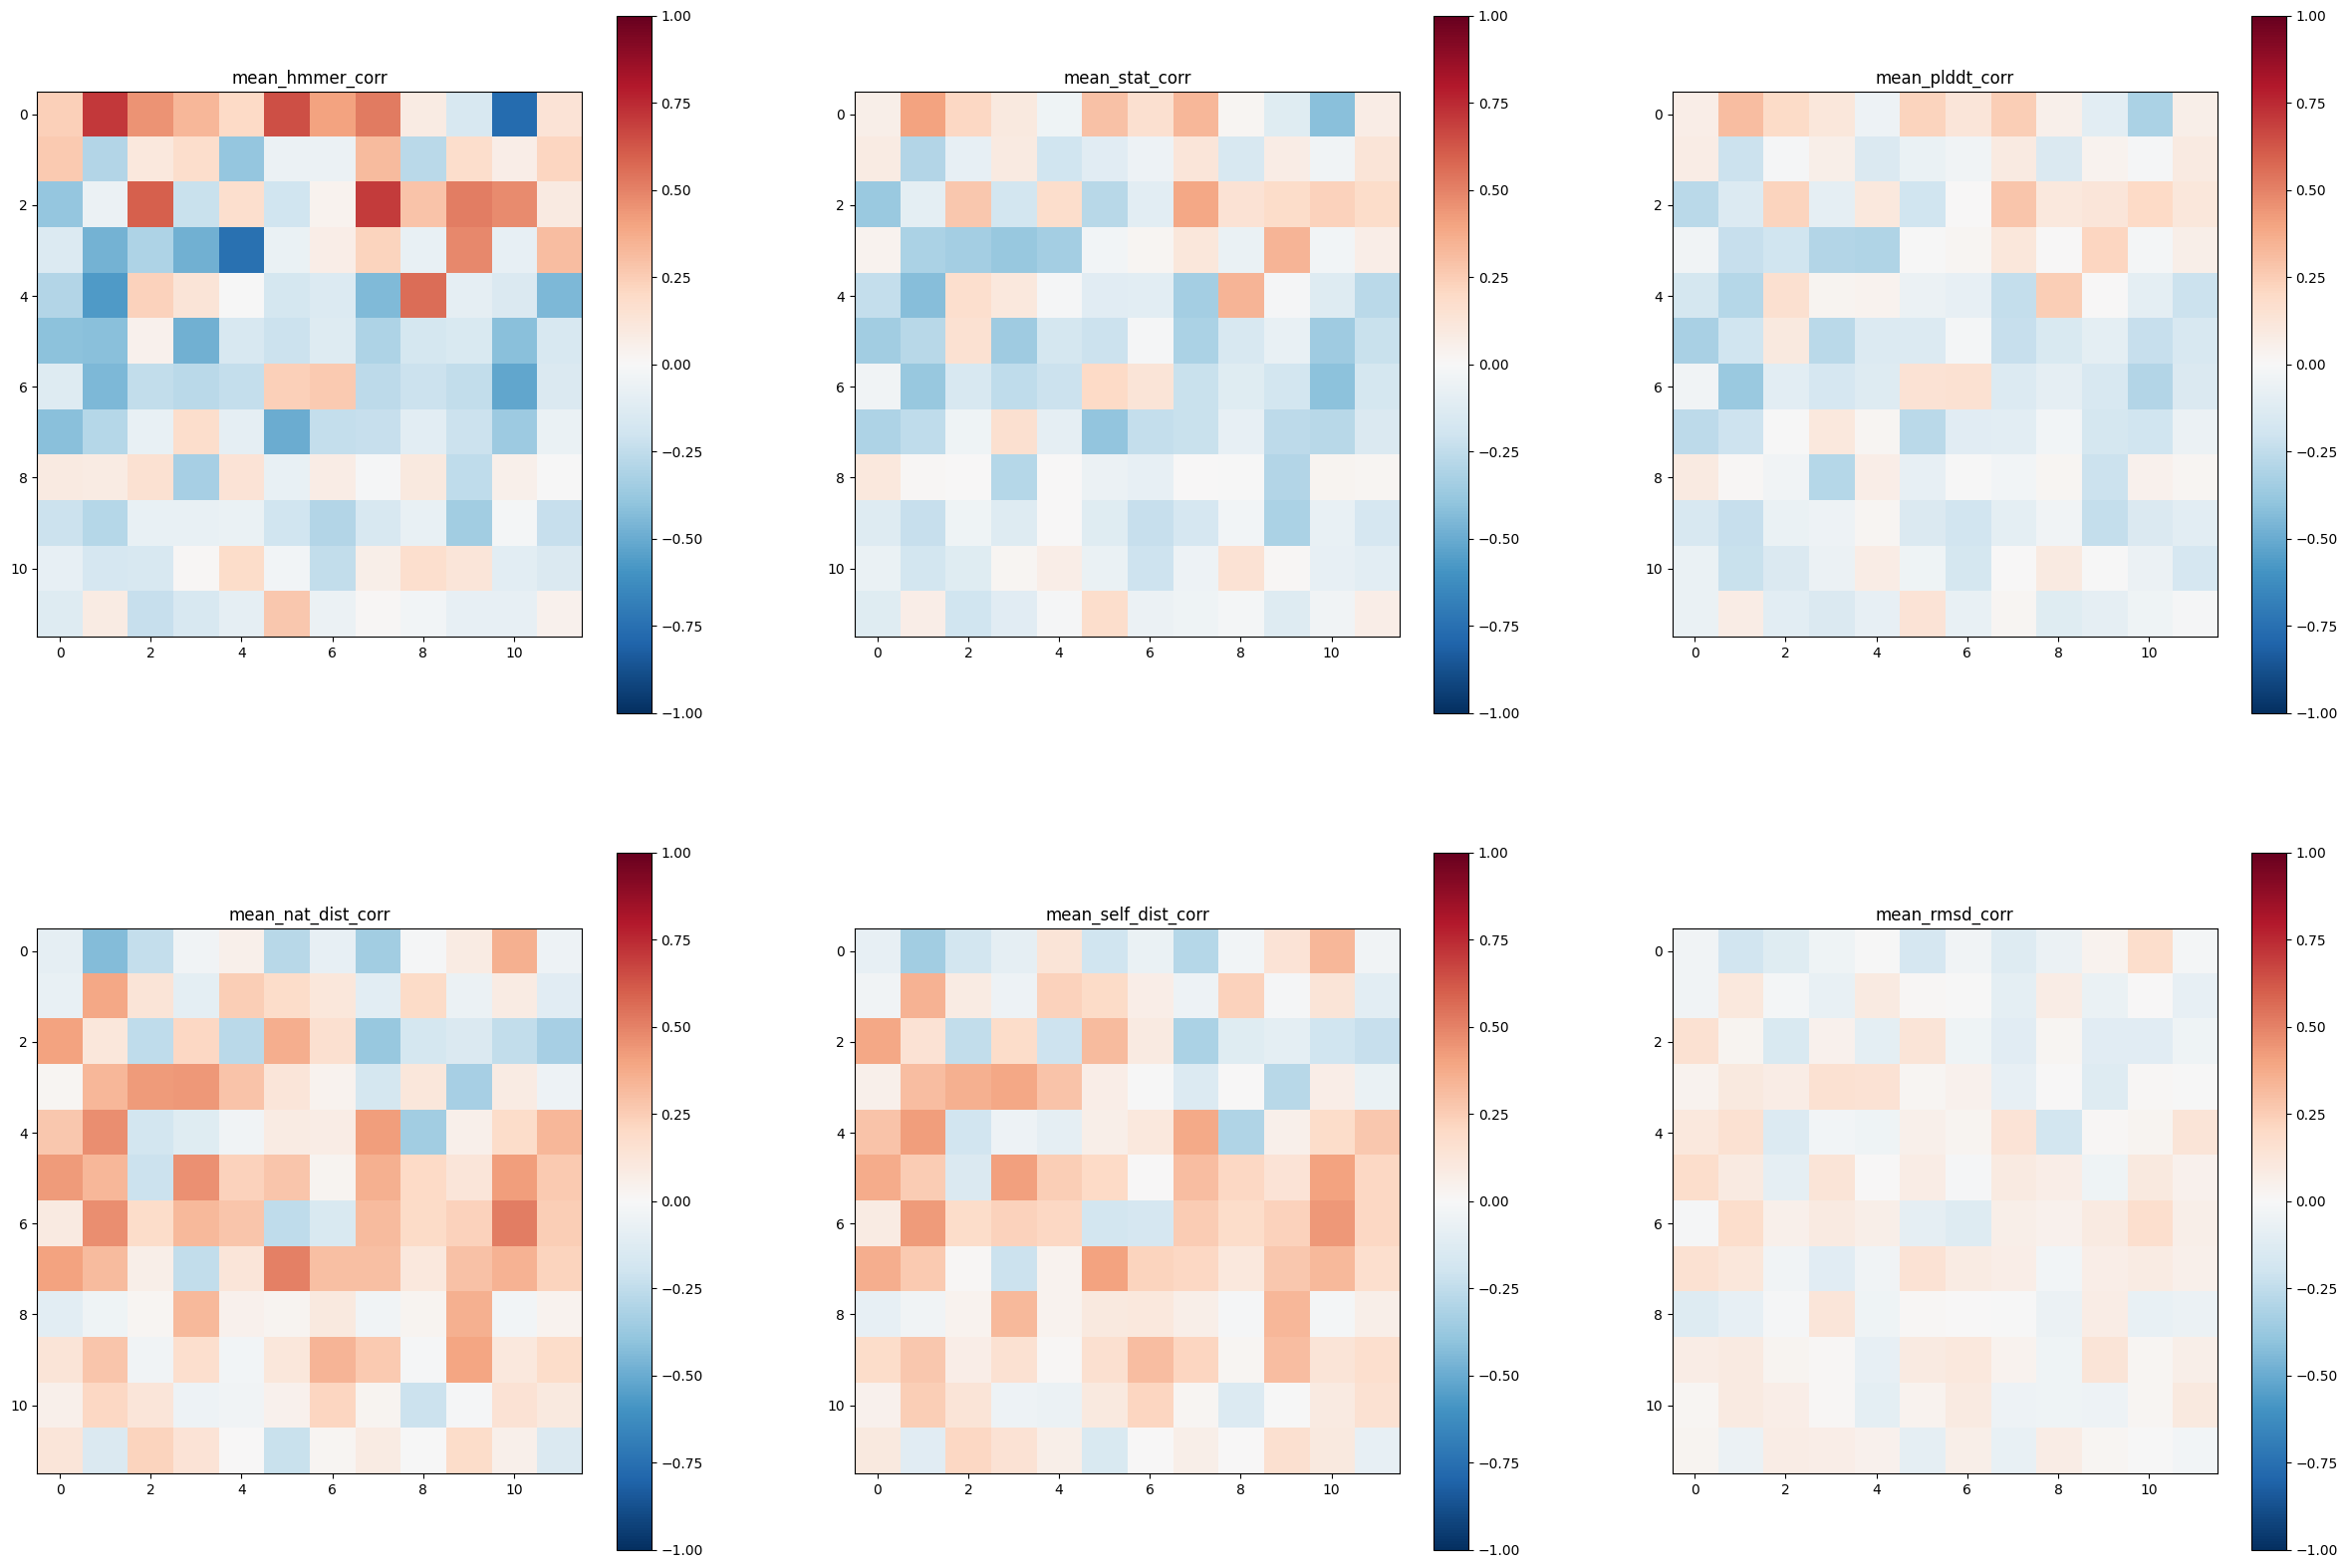

In [ ]:

fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (30,20))

im = axes[0][0].imshow(mean_hmmer_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][0])
axes[0][0].set_title(f"mean_hmmer_corr")

im = axes[0][1].imshow(mean_stat_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][1])
axes[0][1].set_title(f"mean_stat_corr")

im = axes[0][2].imshow(mean_plddt_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][2])
axes[0][2].set_title(f"mean_plddt_corr")

im = axes[1][0].imshow(mean_nat_dist_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][0])
axes[1][0].set_title(f"mean_nat_dist_corr")

im = axes[1][1].imshow(mean_self_dist_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][1])
axes[1][1].set_title(f"mean_self_dist_corr")

im = axes[1][2].imshow(mean_rmsd_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][2])
axes[1][2].set_title(f"mean_rmsd_corr")

# plt.savefig("column_attn_corrs_all_metrics.jpeg")


Text(0.5, 0.9, 'pearson_corr = 0.95')

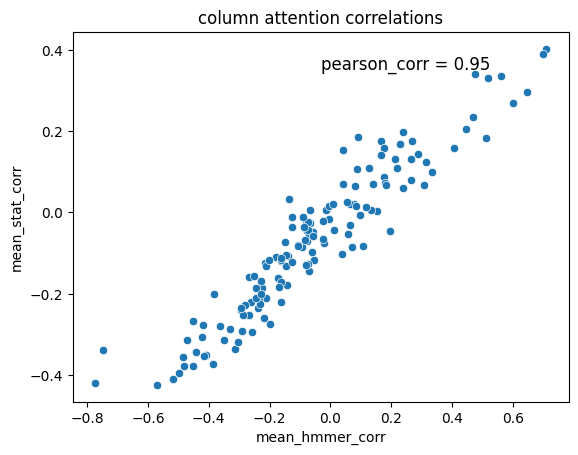

In [ ]:
sns.scatterplot(x =mean_hmmer_corr.flatten(), y=mean_stat_corr.flatten())
plt.xlabel("mean_hmmer_corr")
plt.ylabel("mean_stat_corr")
plt.title("column attention correlations")

pearson_corr = pearsonr(x =mean_hmmer_corr.flatten(), y=mean_stat_corr.flatten())
plt.annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.5,0.9), xycoords = "axes fraction", fontsize = 12)

# plt.savefig("column_attn_scatter_hmmer_vs_nat_dist.jpeg")

Text(0.1, 0.9, 'pearson_corr = 0.91')

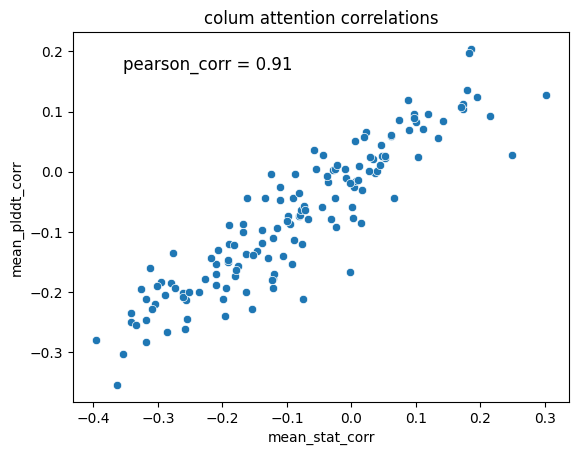

In [ ]:
sns.scatterplot(x =mean_stat_corr.flatten(), y=mean_plddt_corr.flatten())
plt.xlabel("mean_stat_corr")
plt.ylabel("mean_plddt_corr")
plt.title("colum attention correlations")

pearson_corr = pearsonr(x =mean_stat_corr.flatten(), y=mean_plddt_corr.flatten())
plt.annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.1,0.9), xycoords = "axes fraction", fontsize = 12)

# plt.savefig("column_attn_scatter_hmmer_vs_stat.jpeg")

## Attention Scores vs Patristic Distances

In [4]:
def reorder_seqs(tree_root, all_nat_seqs_dict):

    output = []
    
    def reorder_seqs_recur(tree_root, all_nat_seqs_dict):
    
        b = tree_root.clades
        
        if len(b)>0:
            for clade in b:
               reorder_seqs_recur(clade, all_nat_seqs_dict) 
        else:
            output.append((tree_root.name,all_nat_seqs_dict[tree_root.name]))

    reorder_seqs_recur(tree_root, all_nat_seqs_dict)

    return output

### Calculate pairwise patristic and hamming distance

In [13]:
pat_dist_dict = {}

families = list(all_metrics_dataframe["family"].unique())

for k, family in enumerate(families):

    pat_family_dict = {}

    torch.cuda.empty_cache()

    MSA_filename_seed = f"./data/protein-families-msa-seed/{family}_seed.fasta"
    nat_seqs = [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse(MSA_filename_seed, "fasta")]

    tree_path = f"./data/seed-trees/{family}_seed.newick"
    tree = Phylo.read(tree_path,"newick")
    tree.root_at_midpoint()
    
    for i in range(len(nat_seqs)):
            
            for j in range(i, len(nat_seqs)):

                seqname_i = nat_seqs[i][0]
                seqname_j = nat_seqs[j][0]

                pat_dist = tree.distance(seqname_i,seqname_j)
                pat_family_dict[(seqname_i, seqname_j)] = pat_dist
                pat_family_dict[(seqname_j, seqname_i)] = pat_dist
                
    pat_dist_dict[family] = pat_family_dict


In [5]:
import pickle as pkl

with open("pairwise_patristic_distances.pkl", "rb") as handle:
    pat_dist_dict = pkl.load(handle)

In [149]:
def make_train_test_sets(tool,family,seed_number):

    rng_2 = np.random.default_rng(seed=seed_number)
    train_idxs = rng_2.choice(depth, size=n_train, replace=False)
    split_mask = np.zeros(depth, dtype=bool)
    split_mask[train_idxs] = True

    attns_train, attns_test = attns_mean_on_cols_symm[:, :, split_mask, :][:, :, :, split_mask], attns_mean_on_cols_symm[:, :, ~split_mask, :][:, :, :, ~split_mask]
    dists_train, dists_test = hamming_distances[split_mask, :][:, split_mask], hamming_distances[~split_mask, :][:, ~split_mask]
    pat_dists_train, pat_dists_test = pat_dists[split_mask, :][:, split_mask], pat_dists[~split_mask, :][:, ~split_mask]
    
    n_rows_train, n_rows_test = attns_train.shape[-1], attns_test.shape[-1]
    triu_indices_train = np.triu_indices(n_rows_train)
    triu_indices_test = np.triu_indices(n_rows_test)
    
    attns_train = attns_train[..., triu_indices_train[0], triu_indices_train[1]]
    attns_test = attns_test[..., triu_indices_test[0], triu_indices_test[1]]
    dists_train = dists_train[triu_indices_train]
    dists_test = dists_test[triu_indices_test]
    pat_dists_train = pat_dists_train[triu_indices_train]
    pat_dists_test = pat_dists_test[triu_indices_test]
    
    attns_train = attns_train.transpose(2, 0, 1).reshape(-1, n_layers * n_heads)
    attns_test = attns_test.transpose(2, 0, 1).reshape(-1, n_layers * n_heads)

    # del model_output, sequences_tensor, attns_mean_on_cols_symm
    torch.cuda.empty_cache()

    train_df = pd.DataFrame(attns_train, columns = [f"col_attn_{i}" for i in range(144)])
    train_df["tool"] = tool
    train_df["pat_dist"] = pat_dists_train
    train_df["norm_pat_dist"] = train_df["pat_dist"]/pat_dists.max()
    train_df["ham_dist"] = dists_train
    train_df["family"] = family
    train_df["sim_ind"] = sim_ind
    train_df["seed_number"] = seed_number

    # train_df = train_df.loc[train_df["ham_dist"] > 0, :].reset_index(drop=True)

    test_df = pd.DataFrame(attns_test, columns = [f"col_attn_{i}" for i in range(144)])
    test_df["tool"] = tool
    test_df["pat_dist"] = pat_dists_test
    test_df["norm_pat_dist"] = test_df["pat_dist"]/pat_dists.max()
    test_df["ham_dist"] = dists_test
    test_df["family"] = family
    test_df["sim_ind"] = sim_ind
    test_df["seed_number"] = seed_number

    # test_df = test_df.loc[test_df["ham_dist"] > 0, :].reset_index(drop=True)

    return (train_df, test_df)
    

sim_ind = 1
tools = ["nat","MSA-1b-logitsprop-static-10-init-seq-0"]

SEED = 42
train_size = 0.7

families = list(all_metrics_dataframe["family"].unique())
sim_inds = list(range(1,11))

device = "cuda:1"

model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
batch_converter = alphabet.get_batch_converter()
model = model.to(device)
model.eval() 

ncols = 3
nrows = max(2,int(ceil((len(families))/3)))

n_layers = n_heads = 12

all_families_train_df = pd.DataFrame()
all_families_test_df = pd.DataFrame()

corr_matrix_pat_list = []

families = [
    "PF00004",
    "PF00005",
    "PF00041",
    "PF00072",
    "PF00076",
    "PF00096",
    "PF00153",
    "PF00271",
    "PF00397",
    "PF00512",
    "PF00595",
    "PF01535",
    "PF07679",
    "PF13354",
    "PF02518",
    "PF01356",
    "PF03440",
    "PF04008",
    "PF06351",
    "PF06355",
    "PF16747",
    "PF18648"
]

for tool in tools:

    for k, family in enumerate(families):

        torch.cuda.empty_cache()

        MSA_filename_seed = f"./data/protein-families-msa-seed/{family}_seed.fasta"
        nat_seqs = [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse(MSA_filename_seed, "fasta")]

        all_metrics_dataframe_fam = all_metrics_dataframe.loc[(all_metrics_dataframe["family"] == family) & 
                                                        (all_metrics_dataframe["sim_ind"] == sim_ind) &
                                                        (all_metrics_dataframe["tool"] == tool), :].reset_index(drop = True)
        
        if len(all_metrics_dataframe_fam) > 500:
            random_ind = list(np.random.choice(range(len(all_metrics_dataframe_fam)),500, replace = False))
            all_metrics_dataframe_fam = all_metrics_dataframe_fam.iloc[:500, :].reset_index(drop = True)

        sequences = [(name, seq) for name, seq in zip(all_metrics_dataframe_fam["sequence_name"], all_metrics_dataframe_fam["sequence"])]
        device = "cuda:1" if torch.cuda.is_available() else "cpu"

        _,_, sequences_tensor = batch_converter([sequences])
        sequences_tensor = sequences_tensor.to(device)

        model_output = model(sequences_tensor, need_head_weights=True)

        attns_mean_on_cols_symm = model_output["col_attentions"].cpu().numpy()[0, ...].mean(axis=2)
        attns_mean_on_cols_symm += attns_mean_on_cols_symm.transpose(0, 1, 3, 2)

        depth = len(sequences)
        n_train = int(train_size * depth)

        tree_path = f"./data/seed-trees/{family}_seed.newick"
        tree = Phylo.read(tree_path,"newick")
        tree.root_at_midpoint()

        reordered_seqs = reorder_seqs(tree.clade, dict(nat_seqs))
        mapping_dict = {f"seq{i}":reordered_seqs[i][0] for i in range(len(nat_seqs))}

        hamming_distances = squareform(pdist(sequences_tensor.cpu().numpy()[0, :, 1:], "hamming"))

        pat_dists = np.zeros((depth,depth))

        for i in range(len(sequences)):
            for j in range(i, len(sequences)):

                seqname_i = sequences[i][0]
                seqname_j = sequences[j][0]

                if tool != "nat":
                    pat_dist = pat_dist_dict[family][(mapping_dict[seqname_i],mapping_dict[seqname_j])]
                else:
                    pat_dist = pat_dist_dict[family][(seqname_i,seqname_j)]
                
                pat_dists[i,j] = pat_dist
                pat_dists[j,i] = pat_dist        
        
        
        rng = np.random.default_rng(seed=SEED)
        random_seeds = rng.choice(range(10000), size=10, replace=False)

        results = Parallel(n_jobs=10)(delayed(make_train_test_sets)(tool, family, seed_number) for seed_number in random_seeds)

        train_df = pd.concat([item[0] for item in results]).reset_index(drop = True)
        test_df = pd.concat([item[1] for item in results]).reset_index(drop = True)
        
        all_families_train_df = pd.concat([all_families_train_df, train_df]).reset_index(drop = True)
        all_families_test_df = pd.concat([all_families_test_df, test_df]).reset_index(drop = True)
        


In [ ]:
sim_ind = 1
tools = ["nat","MSA-1b-logitsprop-static-10-init-seq-0"]

SEED = 42
train_size = 0.7

families = list(all_metrics_dataframe["family"].unique())
sim_inds = list(range(1,11))

device = "cuda:1"

model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
batch_converter = alphabet.get_batch_converter()
model = model.to(device)
model.eval() 

ncols = 3
nrows = max(2,int(ceil((len(families))/3)))

n_layers = n_heads = 12

all_families_train_df = pd.DataFrame()
all_families_test_df = pd.DataFrame()

corr_matrix_pat_list = []

families = [
    "PF00004",
    "PF00005",
    "PF00041",
    "PF00072",
    "PF00076",
    "PF00096",
    "PF00153",
    "PF00271",
    "PF00397",
    "PF00512",
    "PF00595",
    "PF01535",
    "PF07679",
    "PF13354",
    "PF02518",
    "PF01356",
    "PF03440",
    "PF04008",
    "PF06351",
    "PF06355",
    "PF16747",
    "PF18648"
]

for tool in tools:

    for k, family in enumerate(families):

        torch.cuda.empty_cache()

        MSA_filename_seed = f"./data/protein-families-msa-seed/{family}_seed.fasta"
        nat_seqs = [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse(MSA_filename_seed, "fasta")]

        all_metrics_dataframe_fam = all_metrics_dataframe.loc[(all_metrics_dataframe["family"] == family) & 
                                                        (all_metrics_dataframe["sim_ind"] == sim_ind) &
                                                        (all_metrics_dataframe["tool"] == tool), :].reset_index(drop = True)
        
        if len(all_metrics_dataframe_fam) > 500:
            random_ind = list(np.random.choice(range(len(all_metrics_dataframe_fam)),500, replace = False))
            all_metrics_dataframe_fam = all_metrics_dataframe_fam.iloc[:500, :].reset_index(drop = True)

        sequences = [(name, seq) for name, seq in zip(all_metrics_dataframe_fam["sequence_name"], all_metrics_dataframe_fam["sequence"])]
        device = "cuda:1" if torch.cuda.is_available() else "cpu"

        _,_, sequences_tensor = batch_converter([sequences])
        sequences_tensor = sequences_tensor.to(device)

        model_output = model(sequences_tensor, need_head_weights=True)

        attns_mean_on_cols_symm = model_output["col_attentions"].cpu().numpy()[0, ...].mean(axis=2)
        attns_mean_on_cols_symm += attns_mean_on_cols_symm.transpose(0, 1, 3, 2)

        depth = len(sequences)
        n_train = int(train_size * depth)

        tree_path = f"./data/seed-trees/{family}_seed.newick"
        tree = Phylo.read(tree_path,"newick")
        tree.root_at_midpoint()

        reordered_seqs = reorder_seqs(tree.clade, dict(nat_seqs))
        mapping_dict = {f"seq{i}":reordered_seqs[i][0] for i in range(len(nat_seqs))}

        hamming_distances = squareform(pdist(sequences_tensor.cpu().numpy()[0, :, 1:], "hamming"))

        pat_dists = np.zeros((depth,depth))

        for i in range(len(sequences)):
            for j in range(i, len(sequences)):

                seqname_i = sequences[i][0]
                seqname_j = sequences[j][0]

                if tool != "nat":
                    pat_dist = pat_dist_dict[family][(mapping_dict[seqname_i],mapping_dict[seqname_j])]
                else:
                    pat_dist = pat_dist_dict[family][(seqname_i,seqname_j)]
                
                pat_dists[i,j] = pat_dist
                pat_dists[j,i] = pat_dist        
        
        
        rng = np.random.default_rng(seed=SEED)
        random_seeds = rng.choice(range(10000), size=10, replace=False)

        for seed in random_seeds:

            rng_2 = np.random.default_rng(seed=seed)
            train_idxs = rng_2.choice(depth, size=n_train, replace=False)
            test_idxs = list(set(range(depth)) - set(train_idxs))
            split_mask = np.zeros(depth, dtype=bool)
            split_mask[train_idxs] = True

            attns_train, attns_test = attns_mean_on_cols_symm[:, :, split_mask, :][:, :, :, split_mask], attns_mean_on_cols_symm[:, :, ~split_mask, :][:, :, :, ~split_mask]
            dists_train, dists_test = hamming_distances[split_mask, :][:, split_mask], hamming_distances[~split_mask, :][:, ~split_mask]
            pat_dists_train, pat_dists_test = pat_dists[split_mask, :][:, split_mask], pat_dists[~split_mask, :][:, ~split_mask]
            
            n_rows_train, n_rows_test = attns_train.shape[-1], attns_test.shape[-1]
            triu_indices_train = np.triu_indices(n_rows_train)
            triu_indices_test = np.triu_indices(n_rows_test)
            
            attns_train = attns_train[..., triu_indices_train[0], triu_indices_train[1]]
            attns_test = attns_test[..., triu_indices_test[0], triu_indices_test[1]]
            dists_train = dists_train[triu_indices_train]
            dists_test = dists_test[triu_indices_test]
            pat_dists_train = pat_dists_train[triu_indices_train]
            pat_dists_test = pat_dists_test[triu_indices_test]
            
            attns_train = attns_train.transpose(2, 0, 1).reshape(-1, n_layers * n_heads)
            attns_test = attns_test.transpose(2, 0, 1).reshape(-1, n_layers * n_heads)

            # del model_output, sequences_tensor, attns_mean_on_cols_symm
            torch.cuda.empty_cache()

            train_df = pd.DataFrame(attns_train, columns = [f"col_attn_{i}" for i in range(144)])
            train_df["tool"] = tool
            train_df["pat_dist"] = pat_dists_train
            train_df["norm_pat_dist"] = train_df["pat_dist"]/pat_dists.max()
            train_df["ham_dist"] = dists_train
            train_df["family"] = family
            train_df["sim_ind"] = sim_ind
            train_df["seed_number"] = seed

            # train_df = train_df.loc[train_df["ham_dist"] > 0, :].reset_index(drop=True)

            test_df = pd.DataFrame(attns_test, columns = [f"col_attn_{i}" for i in range(144)])
            test_df["tool"] = tool
            test_df["pat_dist"] = pat_dists_test
            test_df["norm_pat_dist"] = test_df["pat_dist"]/pat_dists.max()
            test_df["ham_dist"] = dists_test
            test_df["family"] = family
            test_df["sim_ind"] = sim_ind
            test_df["seed_number"] = seed

            # test_df = test_df.loc[test_df["ham_dist"] > 0, :].reset_index(drop=True)

            all_families_train_df = pd.concat([all_families_train_df, train_df]).reset_index(drop = True)
            all_families_test_df = pd.concat([all_families_test_df, test_df]).reset_index(drop = True)

In [152]:
all_families_train_df.to_csv("attention_train_df.tsv", sep = "\t", index = False)
all_families_test_df.to_csv("attention_test_df.tsv", sep = "\t", index = False)

In [3]:
from scipy.special import expit, logit
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from patsy import dmatrices
from joblib import Parallel, delayed

epsilon = 1e-6

def safe_logit(y):
    y = np.clip(y, epsilon, 1 - epsilon)
    return logit(y)

regr_results_df = []

def fit_attention_model(train_df, test_df, seed_number):

    train_df_seed = train_df.loc[train_df["seed_number"] == seed_number, :].reset_index(drop = True)
    test_df_seed = test_df.loc[test_df["seed_number"] == seed_number, :].reset_index(drop = True)


    df_train = train_df_seed[attention_cols + [response_col]]
    df_test = test_df_seed[attention_cols + [response_col]]

    formula = f"{response_col} ~ " + " + ".join(attention_cols)
    y_train, X_train = dmatrices(formula, df_train, return_type="dataframe")
    y_test, X_test = dmatrices(formula, df_test, return_type="dataframe")


    binom_model = sm.GLM(y_train, X_train, family=sm.families.Binomial())
    binom_model_results = binom_model.fit(maxiter=500, tol=1e-9)

    y_pred_test = binom_model_results.predict(X_test)
    y_pred_train = binom_model_results.predict(X_train)

    y_train = y_train[response_col]
    y_test = y_test[response_col]

    n_samples_train = len(y_train)
    n_samples_test = len(y_test)

    
    small_inds = y_test <= 0.4
    large_inds = y_test > 0.4

    small_test = y_test[small_inds]
    big_test = y_test[large_inds]

    small_pred_test = y_pred_test[small_inds]
    large_pred_test = y_pred_test[large_inds]
    
    regr_results_df.append({   
        "family":family, 
        "seed_number":seed_number ,
        "RMSE (training)": np.linalg.norm(y_train - y_pred_train) / np.sqrt(n_samples_train),
        "RMSE (test)": np.linalg.norm(y_test - y_pred_test) / np.sqrt(n_samples_test),
        "MAE (training)": np.sum(np.abs(y_train - y_pred_train)) / n_samples_train,
        "MAE (test)": np.sum(np.abs(y_test - y_pred_test)) / n_samples_test,
        "R^2 (test)" : r2_score(y_test, y_pred_test),
        "R^2 (small test)" : r2_score(small_test, small_pred_test),
        "R^2 (large test)" : r2_score(large_test, large_pred_test),
        "Pearson (test)" : pearsonr(y_test, y_pred_test).statistic
        })
    
    return regr_results

attention_cols = [f"col_attn_{i}" for i in range(144)]
response_col = "ham_dist"

regr_results_df = []

all_families_train_df = pd.read_csv("attention_train_df.tsv", delimiter = "\t")
all_families_train_df = all_families_train_df.loc[all_families_train_df["ham_dist"] > 0, :]

all_families_test_df = pd.read_csv("attention_test_df.tsv", delimiter = "\t")
all_families_test_df = all_families_test_df.loc[all_families_test_df["ham_dist"] > 0, :]


for tool in tools:

    for family in all_families_train_df["family"].unique():
            
            print(family)

            all_families_train_df_fam = all_families_train_df.loc[(all_families_train_df["family"] == family) & (all_families_train_df["tool"] == tool), :].reset_index(drop = True)
            all_families_test_df_fam = all_families_test_df.loc[(all_families_test_df["family"] == family) & (all_families_test_df["tool"] == tool), :].reset_index(drop = True)

            seed_numbers = list(all_families_train_df_fam["seed_number"].unique())

            results = Parallel(n_jobs=10)(delayed(fit_attention_model)(all_families_train_df_fam, all_families_test_df_fam, seed_number) for seed_number in seed_numbers)

            regr_results_df += results


regr_results_df = pd.DataFrame(regr_results_df)

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [143]:
all_families_train_df = pd.read_csv("attention_train_df.tsv", delimiter = "\t")


In [170]:
all_families_train_df

,col_attn_0,col_attn_1,col_attn_2,col_attn_3,col_attn_4,col_attn_5,col_attn_6,col_attn_7,col_attn_8,col_attn_9,...,col_attn_141,col_attn_142,col_attn_143,tool,pat_dist,norm_pat_dist,ham_dist,family,sim_ind,seed_number
0,0.064172,0.051565,0.046673,0.145983,0.015148,0.036519,0.085585,0.056479,0.039185,0.049036,...,0.015430,0.046665,0.412432,nat,0.000000,0.000000,0.000000,PF00004,1,859
1,0.053094,0.071698,0.088997,0.154210,0.015580,0.053137,0.094280,0.103613,0.125782,0.040733,...,0.012867,0.041955,0.307032,nat,0.247460,0.035336,0.196970,PF00004,1,859
2,0.052987,0.059584,0.052395,0.134663,0.019735,0.032226,0.091344,0.090974,0.067432,0.022720,...,0.014163,0.023039,0.036244,nat,0.898030,0.128234,0.371212,PF00004,1,859
3,0.051480,0.059538,0.053654,0.132383,0.017461,0.033158,0.082824,0.091755,0.067835,0.027022,...,0.014153,0.023646,0.039791,nat,0.788790,0.112635,0.348485,PF00004,1,859
4,0.043442,0.066200,0.068756,0.119899,0.012555,0.049064,0.076196,0.088772,0.089199,0.036724,...,0.014315,0.042608,0.280809,nat,0.325940,0.046543,0.242424,PF00004,1,859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6848515,0.194338,0.175243,0.161556,0.207924,0.208337,0.129170,0.214170,0.181130,0.167344,0.158404,...,0.214036,0.204090,0.172611,MSA-1b-logitsprop-static-10-init-seq-0,3.279910,0.963073,0.683871,PF18648,1,8582
6848516,0.197359,0.173142,0.149447,0.204472,0.219427,0.112105,0.211078,0.168399,0.148850,0.121356,...,0.196543,0.182438,0.091415,MSA-1b-logitsprop-static-10-init-seq-0,2.718963,0.798363,0.729032,PF18648,1,8582
6848517,0.211627,0.255693,0.582465,0.156361,0.068435,0.621006,0.129245,0.195746,0.446790,0.652698,...,0.208635,0.250789,0.308608,MSA-1b-logitsprop-static-10-init-seq-0,0.000000,0.000000,0.000000,PF18648,1,8582
6848518,0.200892,0.181648,0.187026,0.213259,0.198397,0.149935,0.183825,0.177727,0.194867,0.163168,...,0.180552,0.229026,0.332919,MSA-1b-logitsprop-static-10-init-seq-0,2.412928,0.708502,0.632258,PF18648,1,8582


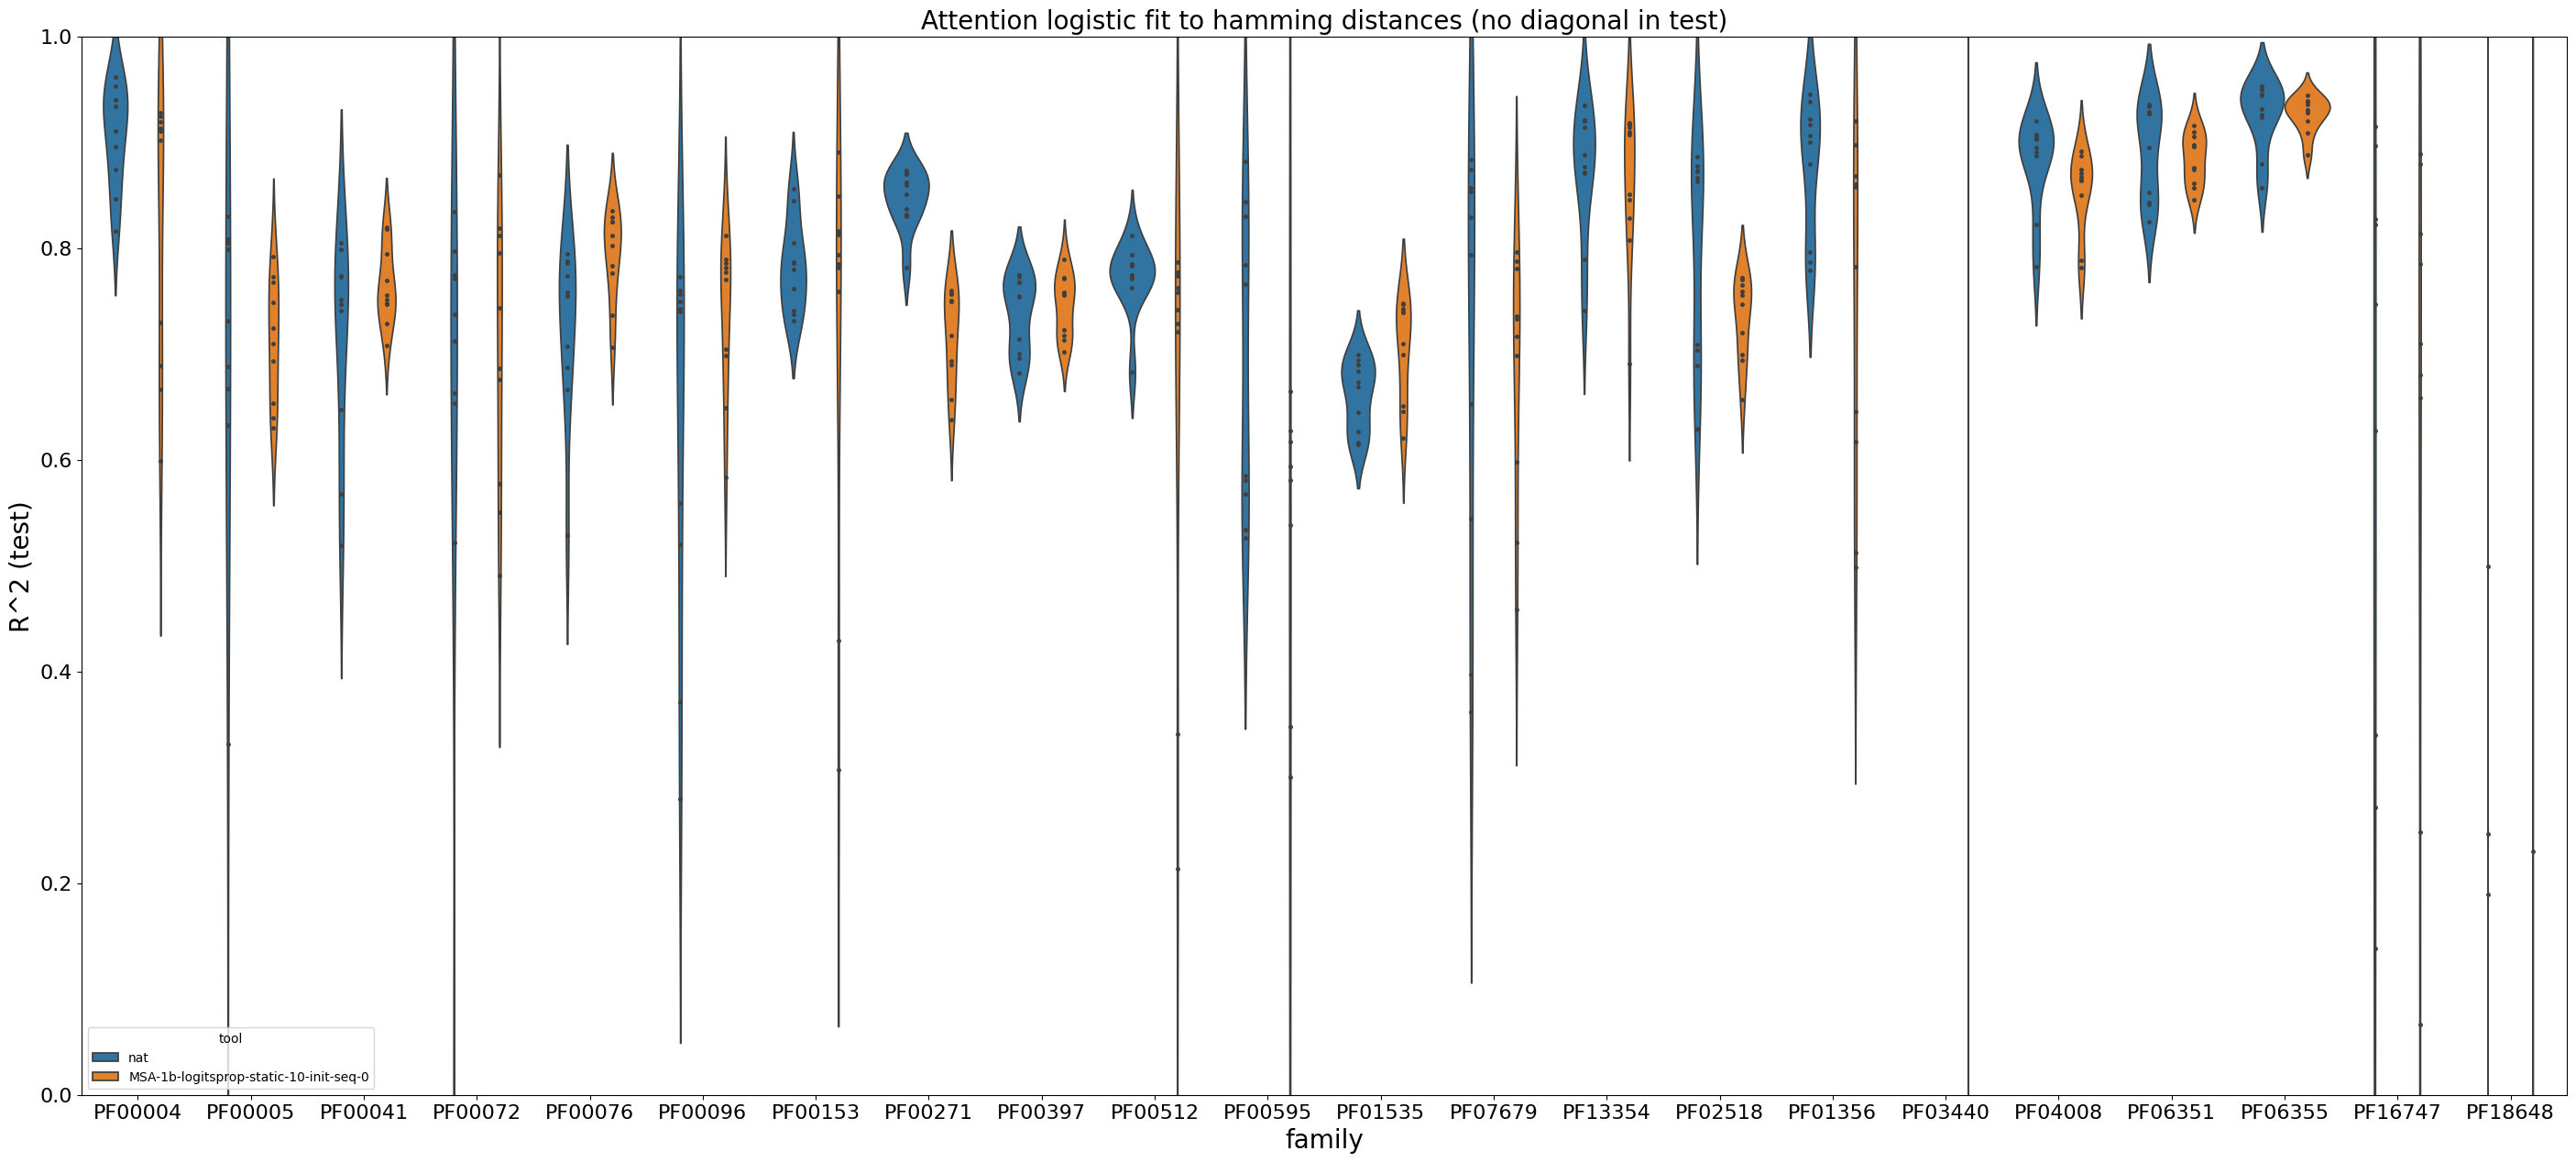

In [168]:
rcParams['figure.figsize'] = 35,15
plt.rc('xtick', labelsize=16)
plt.rc('ytick', labelsize=16)    # fontsize of the tick labels

fig, axes = plt.subplots()

sns.violinplot(data = regr_results_df, x = "family", y = "R^2 (test)", hue = "tool", ax = axes, inner = "point")

axes.set_ylim([0,1])
axes.set_title("Attention logistic fit to hamming distances (no diagonal in test)", fontdict={"size":20})

plt.savefig("r2_attnfit_ham_dist_nat_vs_MSA_no_test_diagonal.png")



In [59]:
regr_results_df

,family,seed_number,RMSE (training),RMSE (test),MAE (training),MAE (test),R^2 (test),Pearson (test)
0,PF00004,859,2.547660e-02,2.546212e-02,1.982406e-02,1.965581e-02,0.957535,0.978561
1,PF00004,7733,2.547660e-02,2.546212e-02,1.982406e-02,1.965581e-02,0.957535,0.978561
2,PF00004,891,2.547660e-02,2.546212e-02,1.982406e-02,1.965581e-02,0.957535,0.978561
3,PF00004,6541,2.547660e-02,2.546212e-02,1.982406e-02,1.965581e-02,0.957535,0.978561
4,PF00004,4386,2.547660e-02,2.546212e-02,1.982406e-02,1.965581e-02,0.957535,0.978561
...,...,...,...,...,...,...,...,...
205,PF18648,4327,4.270687e-12,5.009122e-14,9.432595e-13,1.846671e-14,1.000000,1.000000
206,PF18648,6972,4.270687e-12,5.009122e-14,9.432595e-13,1.846671e-14,1.000000,1.000000
207,PF18648,941,4.270687e-12,5.009122e-14,9.432595e-13,1.846671e-14,1.000000,1.000000
208,PF18648,2014,4.270687e-12,5.009122e-14,9.432595e-13,1.846671e-14,1.000000,1.000000


In [ ]:
from scipy.special import expit, logit
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from patsy import dmatrices

epsilon = 1e-6

def safe_logit(y):
    y = np.clip(y, epsilon, 1 - epsilon)
    return logit(y)

attention_cols = [f"col_attn_{i}" for i in range(144)]
response_col = "ham_dist"

regr_results = {}

regr_results_df = []
    
for family in all_families_train_df["family"].unique():
        
        print(family)

        all_families_train_df_fam = all_families_train_df.loc[all_families_train_df["family"] == family, :].reset_index(drop = True)
        all_families_test_df_fam = all_families_test_df.loc[all_families_test_df["family"] == family, :].reset_index(drop = True)

        for seed_number in all_families_train_df_fam["seed_number"].unique():
              
            all_families_train_df_fam_seed = all_families_train_df.loc[all_families_train_df["seed_number"] == seed_number, :].reset_index(drop = True)
            all_families_test_df_fam_seed = all_families_test_df.loc[all_families_test_df["seed_number"] == seed_number, :].reset_index(drop = True)

            df_train = all_families_train_df_fam_seed[attention_cols + [response_col]]
            df_test = all_families_test_df_fam_seed[attention_cols + [response_col]]

            formula = f"{response_col} ~ " + " + ".join(attention_cols)
            y_train, X_train = dmatrices(formula, df_train, return_type="dataframe")
            y_test, X_test = dmatrices(formula, df_test, return_type="dataframe")

            binom_model = sm.GLM(y_train, X_train, family=sm.families.Binomial())
            binom_model_results = binom_model.fit(maxiter=500, tol=1e-9)

            y_pred_test = binom_model_results.predict(X_test)
            y_pred_train = binom_model_results.predict(X_train)

            y_train = y_train[response_col]
            y_test = y_test[response_col]
            # X_train = all_families_train_df_fam_seed[attention_cols]
            # X_test = all_families_test_df_fam_seed[attention_cols]

            # y_train = all_families_train_df_fam_seed[response_col]
            # y_test = all_families_test_df_fam_seed[response_col]

            # X_train = add_constant(X_train)
            # X_test = add_constant(X_test)

            # logistic_regressor = TransformedTargetRegressor(regressor=LinearRegression(),
            #                                 func=safe_logit, inverse_func=expit)
            
            # logistic_regressor.fit(X_train, y_train)
            # coefs = logistic_regressor.regressor_.coef_

            # y_pred = logistic_regressor.predict(X_test)
            # r2 = r2_score(y_test, y_pred)

            n_samples_train = len(y_train)
            n_samples_test = len(y_test)

            # regr_results[family] = {
            #     "bias": binom_model_results.params[0],
            #     "coeffs": binom_model_results.params.to_numpy()[-n_layers * n_heads:].reshape(n_layers, n_heads),
            #     "y_train": y_train,
            #     "y_pred_train": y_pred_train,
            #     "y_test": y_test,
            #     "y_pred_test": y_pred_test,
            #     "depth": len(df_train) + len(df_test),
            #     "n_rows_train": n_rows_train,
            #     "n_rows_test": n_rows_test,
            #     "RMSE (training)": np.linalg.norm(y_train - y_pred_train) / np.sqrt(n_samples_train),
            #     "RMSE (test)": np.linalg.norm(y_test - y_pred_test) / np.sqrt(n_samples_test),
            #     "MAE (training)": np.sum(np.abs(y_train - y_pred_train)) / n_samples_train,
            #     "MAE (test)": np.sum(np.abs(y_test - y_pred_test)) / n_samples_test,
            #     "R^2 (test)" : r2_score(y_test, y_pred_test),
            #     "Pearson (test)" : pearsonr(y_test[response_col], y_pred_test).statistic
            #     }

            small_inds = y_test <= 0.4
            large_inds = y_test > 0.4

            small_test = y_test[small_inds]
            big_test = y_test[large_inds]

            small_pred_test = y_pred_test[small_inds]
            large_pred_test = y_pred_test[large_inds]
            
            regr_results_df.append({   
                "family":family, 
                "seed_number":seed_number ,
                "RMSE (training)": np.linalg.norm(y_train - y_pred_train) / np.sqrt(n_samples_train),
                "RMSE (test)": np.linalg.norm(y_test - y_pred_test) / np.sqrt(n_samples_test),
                "MAE (training)": np.sum(np.abs(y_train - y_pred_train)) / n_samples_train,
                "MAE (test)": np.sum(np.abs(y_test - y_pred_test)) / n_samples_test,
                "R^2 (test)" : r2_score(y_test, y_pred_test),
                "R^2 (small test)" : r2_score(small_test, small_pred_test),
                "R^2 (large test)" : r2_score(large_test, large_pred_test),
                "Pearson (test)" : pearsonr(y_test, y_pred_test).statistic
                })

    

regr_results_df = pd.DataFrame(regr_results_df)


PF00004
PF00005
PF00041
PF00072
PF00076
PF00096
PF00153
PF00271
PF00397
PF00512
PF00595
PF01535
PF07679
PF13354
PF01356
PF03440
PF04008
PF06351
PF06355
PF16747
PF18648


In [56]:
regr_results_df.to_csv("nat_norm_pat_dist_attention_fit_metrics.tsv", sep = "\t", index = False)

In [ ]:
from sklearn.metrics import r2_score

df_regr_results_hamming_msawise = pd.DataFrame()
for pfam_family in families:

    # if pfam_family == "PF02518":
    #     continue
    
    res = regr_results[pfam_family]
    for key in res:
        exec(f"{key} = res['{key}']")
    n_samples_train = len(y_train)
    n_samples_test = len(y_test)
    df_regr_results_hamming_msawise.loc[pfam_family, "Depth"] = depth
    
    df_regr_results_hamming_msawise.loc[pfam_family, "mean (training)"] = np.mean(y_train)
    df_regr_results_hamming_msawise.loc[pfam_family, "mean (test)"] = np.mean(y_test)
    df_regr_results_hamming_msawise.loc[pfam_family, "std (training)"] = np.std(y_train)
    df_regr_results_hamming_msawise.loc[pfam_family, "std (test)"] = np.std(y_test)
    
    df_regr_results_hamming_msawise.loc[pfam_family, "RMSE (training)"] = np.linalg.norm(y_train - y_pred_train) / np.sqrt(n_samples_train)
    df_regr_results_hamming_msawise.loc[pfam_family, "RMSE (test)"] = np.linalg.norm(y_test - y_pred_test) / np.sqrt(n_samples_test)
    df_regr_results_hamming_msawise.loc[pfam_family, "MAE (training)"] = np.sum(np.abs(y_train - y_pred_train)) / n_samples_train
    df_regr_results_hamming_msawise.loc[pfam_family, "MAE (test)"] = np.sum(np.abs(y_test - y_pred_test)) / n_samples_test
    
    df_regr_results_hamming_msawise.loc[pfam_family, "R^2 (test)"] = r2_score(y_test, y_pred_test)
    pearson = pearsonr(y_test, y_pred_test)[0]
    df_regr_results_hamming_msawise.loc[pfam_family, "Pearson (test)"] = pearson
    df_regr_results_hamming_msawise.loc[pfam_family, "Slope (test)"] = pearson * np.std(y_pred_test) / np.std(y_test)

df_regr_results_hamming_msawise

,Depth,mean (training),mean (test),std (training),std (test),RMSE (training),RMSE (test),MAE (training),MAE (test),R^2 (test),Pearson (test),Slope (test)
PF00004,207.0,0.460015,0.496621,0.180464,0.184537,6.296825e-02,0.080537,4.794712e-02,0.062244,0.809528,0.901149,0.811216
PF00005,55.0,0.571134,0.602637,0.110340,0.156944,3.391046e-02,0.118636,2.667198e-02,0.088346,0.428597,0.782467,0.529392
PF00041,98.0,0.553209,0.545966,0.125533,0.110616,6.705400e-02,0.081140,5.295729e-02,0.062687,0.461928,0.780212,0.846163
PF00072,52.0,0.630471,0.602559,0.138902,0.107052,4.086680e-02,0.126720,3.269930e-02,0.089343,-0.401221,0.636048,0.973103
PF00076,68.0,0.607037,0.678735,0.131238,0.129725,5.056650e-02,0.101143,3.998629e-02,0.078729,0.392111,0.745640,0.850991
PF00096,159.0,0.408810,0.416747,0.141206,0.117642,6.980958e-02,0.075846,5.560109e-02,0.058143,0.584343,0.778210,0.636885
PF00153,160.0,0.625276,0.622517,0.125934,0.112823,6.680219e-02,0.096700,5.332181e-02,0.075529,0.265400,0.615266,0.551453
PF00271,421.0,0.319901,0.331685,0.078978,0.103988,4.159136e-02,0.056620,3.306087e-02,0.040834,0.703529,0.844856,0.638008
PF00397,448.0,0.421681,0.435071,0.146495,0.147971,9.423322e-02,0.104084,7.540887e-02,0.081332,0.505210,0.716123,0.558105
PF00512,265.0,0.489877,0.469785,0.144355,0.138323,7.722614e-02,0.088018,6.121058e-02,0.066307,0.595098,0.793220,0.773122


### Embeddings

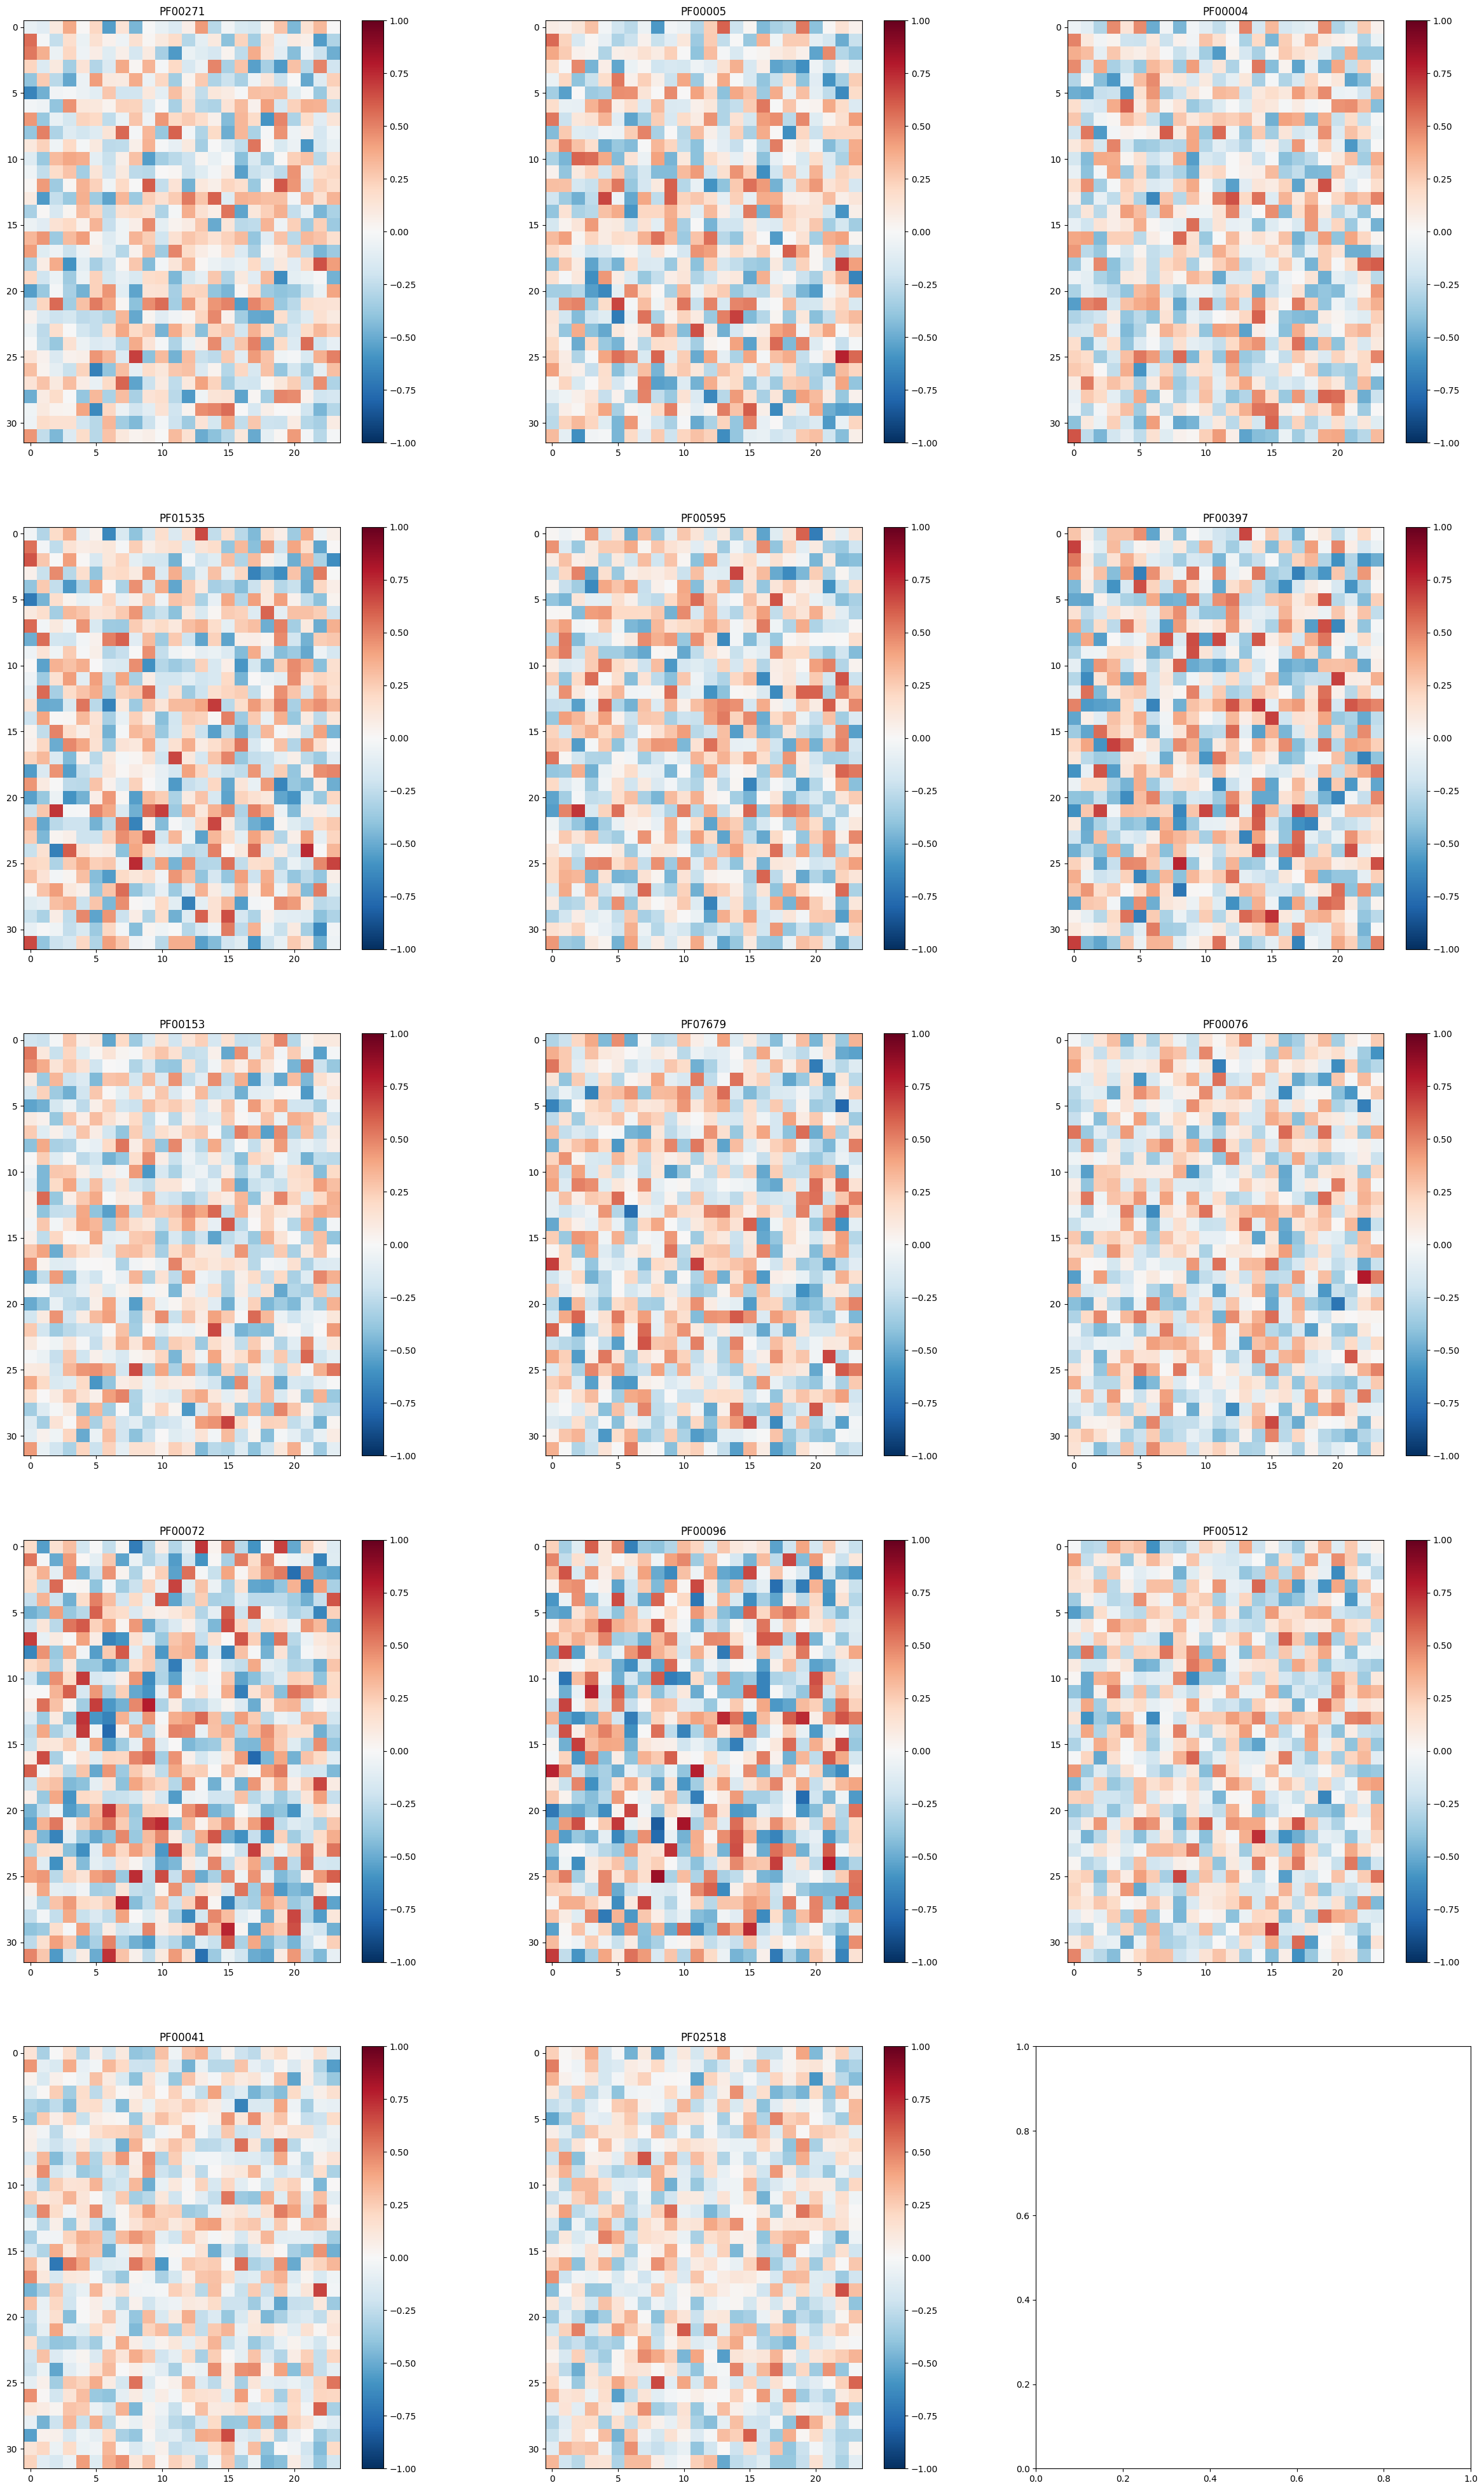

In [12]:
family = "PF00004"
sim_ind = 1
tool = "MSA-1b-logitsprop-static-10-init-seq-0"

families = list(all_metrics_dataframe["family"].unique())
sim_inds = list(range(1,11))

device = "cuda:1"

model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
batch_converter = alphabet.get_batch_converter()
model = model.to(device)
model.eval() 

ncols = 3
nrows = max(2,int(ceil((len(families))/3)))

embed_dim = 768

fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize = (30,10 * nrows))

corr_matrix_hmmer_list = []
corr_matrix_stat_list = []
corr_matrix_plddt_list = []
corr_matrix_nat_dist_list = []
corr_matrix_self_dist_list = []
corr_matrix_rmsd_list = []

for k, family in enumerate(families):

    torch.cuda.empty_cache()

    all_metrics_dataframe_fam = all_metrics_dataframe.loc[(all_metrics_dataframe["pfam_id"] == family) & 
                                                      (all_metrics_dataframe["sim_ind"] == sim_ind) &
                                                      (all_metrics_dataframe["tool"] == tool), :].reset_index(drop = True)

    i = floor(k/3)
    j = k % 3


    if len(all_metrics_dataframe_fam) > 500:
        # random_ind = list(np.random.choice(range(len(all_metrics_dataframe_fam)),500, replace = False))
        all_metrics_dataframe_fam = all_metrics_dataframe_fam.iloc[:500, :].reset_index(drop = True)

    sequences = [(name, seq) for name, seq in zip(all_metrics_dataframe_fam["sequence_name"], all_metrics_dataframe_fam["sequence"])]
    device = "cuda:1" if torch.cuda.is_available() else "cpu"

    _,_, sequences_tensor = batch_converter([sequences])
    sequences_tensor = sequences_tensor.to(device)

    model_output = model(sequences_tensor, need_head_weights=True, repr_layers = [12])
    embeds = model_output["representations"][12][0].cpu().numpy()
    embeds = embeds.mean(axis = 1)

    n_seqs = len(sequences)

    del model_output, sequences_tensor
    torch.cuda.empty_cache()

    embeds_df = pd.DataFrame(embeds, columns = [f"dim_{i}" for i in range(embeds.shape[1])])
    final_df = pd.concat([embeds_df, all_metrics_dataframe_fam], axis = 1)

    corr_matrix_hmmer = np.zeros(embed_dim)
    corr_matrix_stat = np.zeros(embed_dim)
    corr_matrix_plddt = np.zeros(embed_dim)
    corr_matrix_nat_dist = np.zeros(embed_dim)
    corr_matrix_self_dist = np.zeros(embed_dim)
    corr_matrix_rmsd = np.zeros(embed_dim)

    for a in range(len(corr_matrix_hmmer)):

        corr = pearsonr(final_df[f"dim_{a}"], final_df["hmmer_seq_score"]).statistic
        corr_matrix_hmmer[a] = corr

        try:
            corr = pearsonr(final_df[f"dim_{a}"], final_df["stat_energy_scores"]).statistic
            corr_matrix_stat[a] = corr
        except:
            pass

        corr = pearsonr(final_df[f"dim_{a}"], final_df["plddt_scores"]).statistic
        corr_matrix_plddt[a] = corr

        corr = pearsonr(final_df[f"dim_{a}"], final_df["min_natural_ham_dist_seed"]).statistic
        corr_matrix_nat_dist[a] = corr

        corr = pearsonr(final_df[f"dim_{a}"], final_df["max_self_ham_distance"]).statistic
        corr_matrix_self_dist[a] = corr

        corr = pearsonr(final_df[f"dim_{a}"], final_df["rmsd"]).statistic
        corr_matrix_rmsd[a] = corr

    corr_matrix_hmmer = np.reshape(corr_matrix_hmmer, newshape = (32,24), order = "C")
    corr_matrix_stat = np.reshape(corr_matrix_stat, newshape = (32,24), order = "C")
    corr_matrix_plddt = np.reshape(corr_matrix_plddt, newshape = (32,24), order = "C")
    corr_matrix_nat_dist = np.reshape(corr_matrix_nat_dist, newshape = (32,24), order = "C")
    corr_matrix_self_dist = np.reshape(corr_matrix_self_dist, newshape = (32,24), order = "C")
    corr_matrix_rmsd = np.reshape(corr_matrix_rmsd, newshape = (32,24), order = "C")

    corr_matrix_hmmer_list.append(corr_matrix_hmmer)
    corr_matrix_stat_list.append(corr_matrix_stat)
    corr_matrix_plddt_list.append(corr_matrix_plddt)
    corr_matrix_nat_dist_list.append(corr_matrix_nat_dist)
    corr_matrix_self_dist_list.append(corr_matrix_self_dist)
    corr_matrix_rmsd_list.append(corr_matrix_rmsd)

    im = axes[i][j].imshow(corr_matrix_hmmer, vmin = -1, vmax = 1, cmap = "RdBu_r")
    plt.colorbar(im, ax=axes[i][j])
    axes[i][j].set_title(f"{family}")

In [13]:
mean_hmmer_corr = np.stack(corr_matrix_hmmer_list).mean(axis=0)
mean_stat_corr = np.stack(corr_matrix_stat_list).mean(axis=0)
mean_plddt_corr = np.stack(corr_matrix_plddt_list).mean(axis=0)
mean_nat_dist_corr = np.stack(corr_matrix_nat_dist_list).mean(axis=0)
mean_self_dist_corr = np.stack(corr_matrix_self_dist_list).mean(axis=0)
mean_rmsd_corr = np.stack(corr_matrix_rmsd_list).mean(axis=0)

Text(0.5, 1.0, 'mean_rmsd_corr')

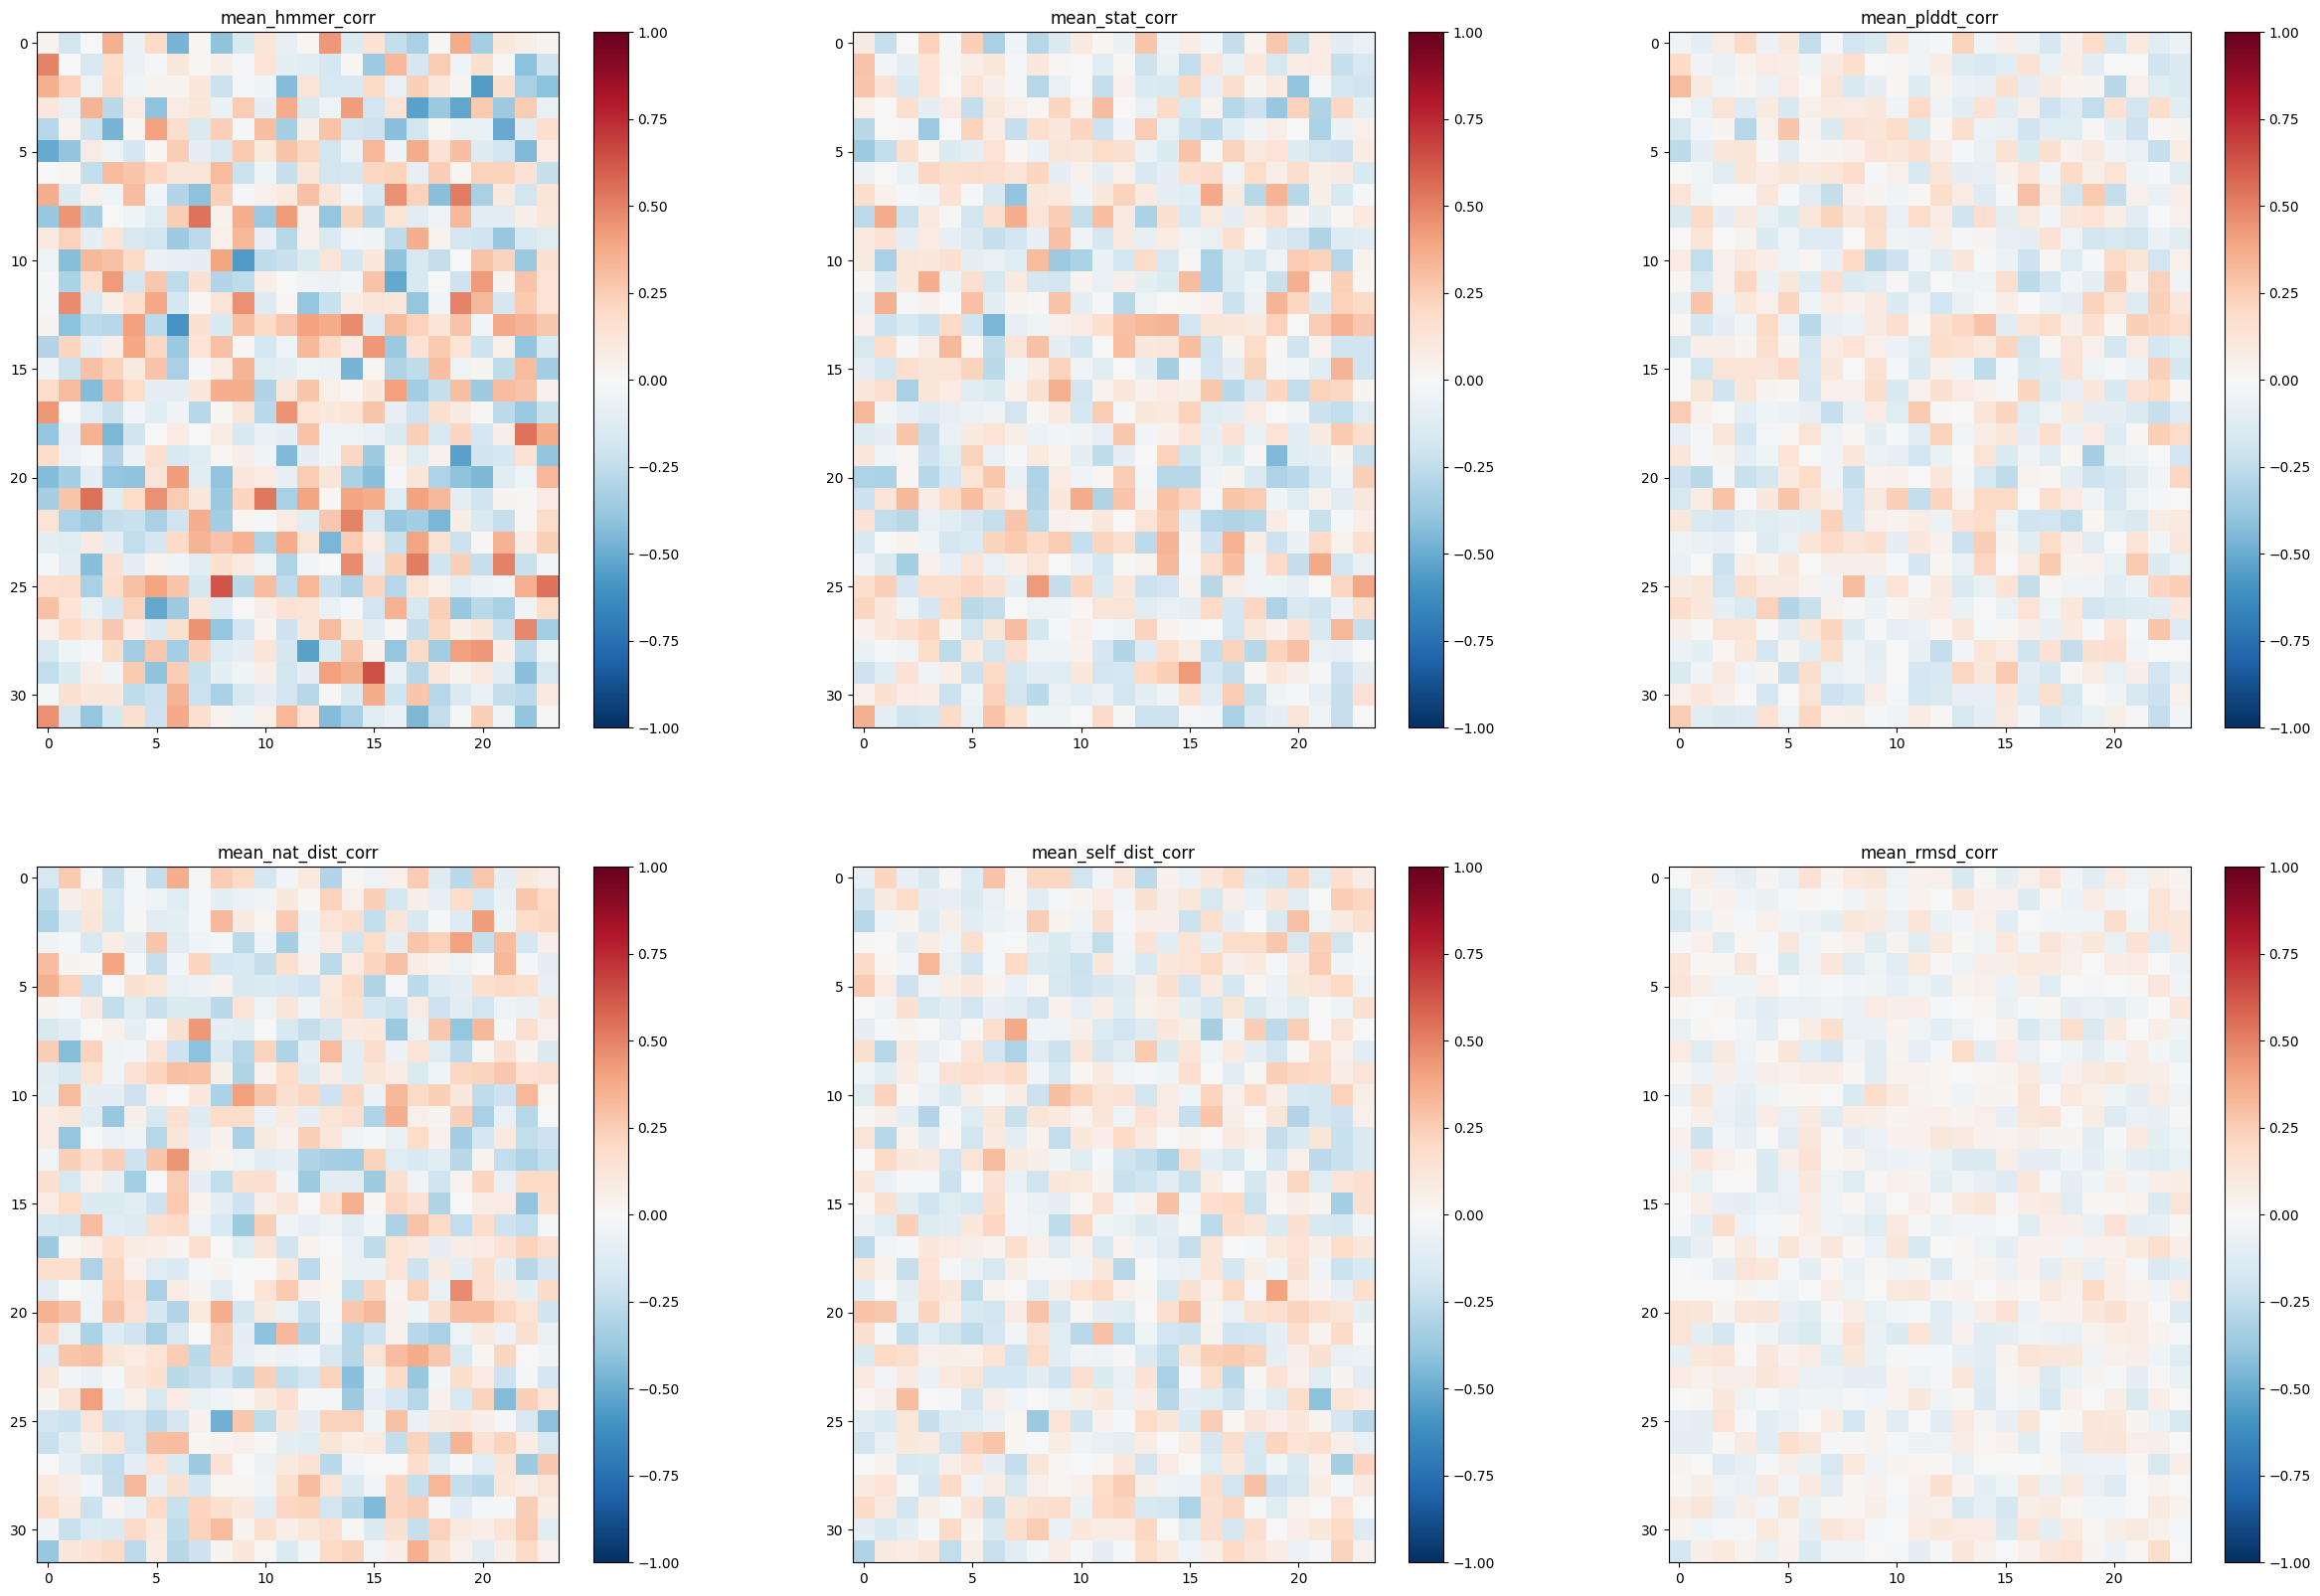

In [14]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (30,20))

im = axes[0][0].imshow(mean_hmmer_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][0])
axes[0][0].set_title(f"mean_hmmer_corr")

im = axes[0][1].imshow(mean_stat_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][1])
axes[0][1].set_title(f"mean_stat_corr")

im = axes[0][2].imshow(mean_plddt_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][2])
axes[0][2].set_title(f"mean_plddt_corr")

im = axes[1][0].imshow(mean_nat_dist_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][0])
axes[1][0].set_title(f"mean_nat_dist_corr")

im = axes[1][1].imshow(mean_self_dist_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][1])
axes[1][1].set_title(f"mean_self_dist_corr")

im = axes[1][2].imshow(mean_rmsd_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][2])
axes[1][2].set_title(f"mean_rmsd_corr")

Text(0.5, 0.9, 'pearson_corr = 0.90')

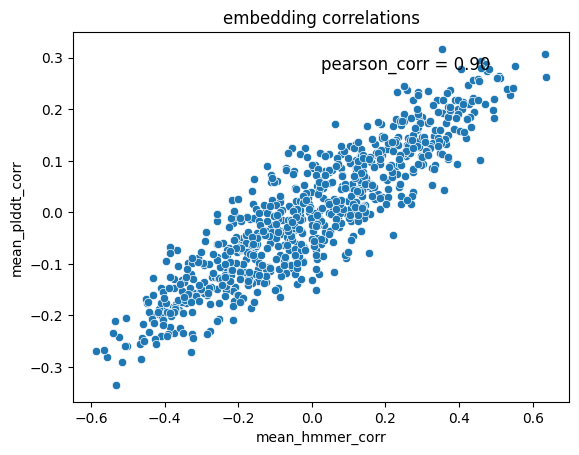

In [16]:
sns.scatterplot(x =mean_hmmer_corr.flatten(), y=mean_plddt_corr.flatten())
plt.xlabel("mean_hmmer_corr")
plt.ylabel("mean_plddt_corr")
plt.title("embedding correlations")

pearson_corr = pearsonr(x =mean_hmmer_corr.flatten(), y=mean_plddt_corr.flatten())
plt.annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.5,0.9), xycoords = "axes fraction", fontsize = 12)

### ESM2 Attentions

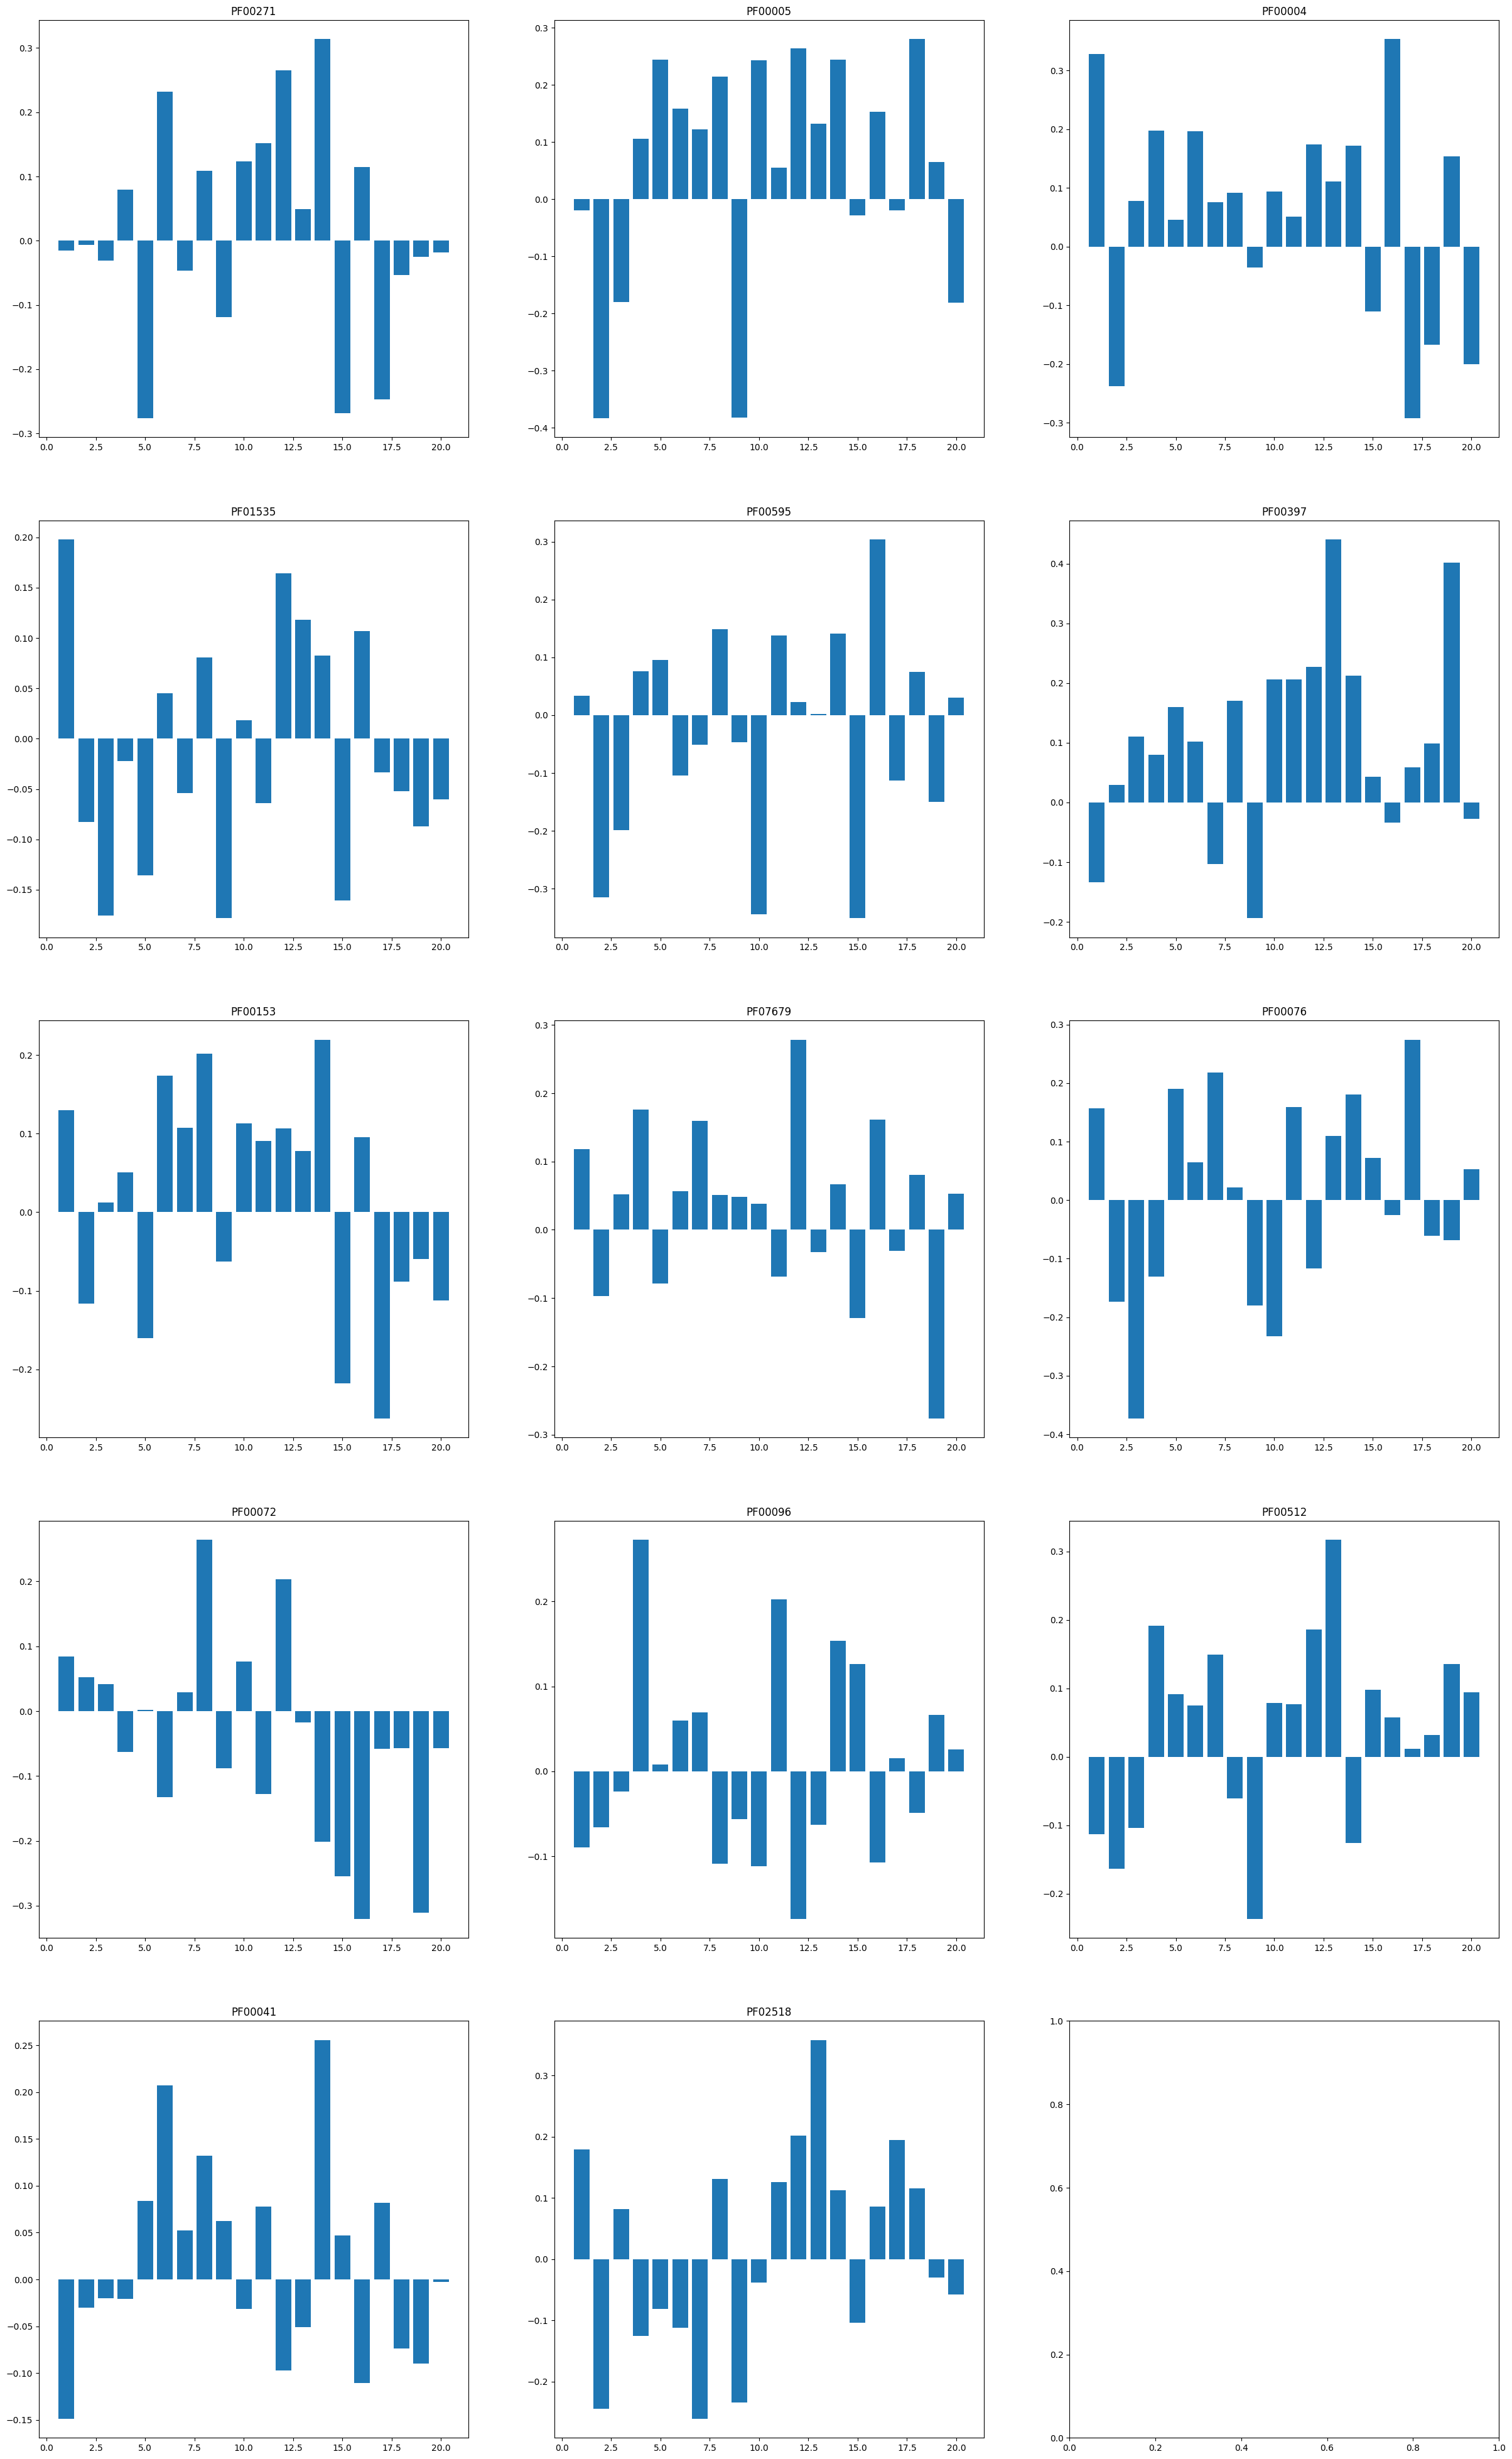

In [42]:
family = "PF00004"
sim_ind = 1
tool = "MSA-1b-logitsprop-static-10-init-seq-0"

families = list(all_metrics_dataframe["family"].unique())
sim_inds = list(range(1,11))

device = "cuda:1"

from transformers import EsmForMaskedLM, EsmTokenizer

model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = EsmTokenizer.from_pretrained(model_name)
model = EsmForMaskedLM.from_pretrained(model_name, output_attentions=True)
model = model.to(device)

model.eval()

ncols = 3
nrows = max(2,int(ceil((len(families))/3)))

fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize = (30,10 * nrows))

corr_matrix_hmmer_list = []
corr_matrix_stat_list = []
corr_matrix_plddt_list = []
corr_matrix_nat_dist_list = []
corr_matrix_self_dist_list = []
corr_matrix_rmsd_list = []

for k, family in enumerate(families):

    torch.cuda.empty_cache()

    all_metrics_dataframe_fam = all_metrics_dataframe.loc[(all_metrics_dataframe["pfam_id"] == family) & 
                                                      (all_metrics_dataframe["sim_ind"] == sim_ind) &
                                                      (all_metrics_dataframe["tool"] == tool), :].reset_index(drop = True)

    i = floor(k/3)
    j = k % 3


    sequences = list(all_metrics_dataframe_fam["sequence"])
    device = "cuda:1" if torch.cuda.is_available() else "cpu"

    inputs = tokenizer(sequences, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions[0]

    # max_attn = attentions.mean(axis = [2]).max(axis = 2).values.cpu().numpy()
    mean_attn = attentions.mean(axis = [2])

    def entropy(x, dim=-1, eps=1e-12):
    # Normalize to make it a probability distribution
        p = x / (x.sum(dim=dim, keepdim=True) + eps)

        # Avoid log(0) by adding small epsilon
        log_p = torch.log(p + eps)

        # Compute entropy: -sum(p * log(p))
        H = - (p * log_p).sum(dim=dim)
        return H

    entropy_attn = entropy(mean_attn, dim=2).cpu().numpy()

    del outputs, inputs, attentions
    torch.cuda.empty_cache()

    max_attn_df = pd.DataFrame(entropy_attn, columns = [f"col_attn_{i}" for i in range(entropy_attn.shape[1])])
    final_df = pd.concat([max_attn_df, all_metrics_dataframe_fam], axis = 1)

    corr_matrix_hmmer = np.zeros(20)
    corr_matrix_stat = np.zeros(20)
    corr_matrix_plddt = np.zeros(20)
    corr_matrix_nat_dist = np.zeros(20)
    corr_matrix_self_dist = np.zeros(20)
    corr_matrix_rmsd = np.zeros(20)

    for a in range(len(corr_matrix_hmmer)):

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["hmmer_seq_score"]).statistic
        corr_matrix_hmmer[a] = corr

        try:
            corr = pearsonr(final_df[f"col_attn_{a}"], final_df["stat_energy_scores"]).statistic
            corr_matrix_stat[a] = corr
        except:
            pass

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["plddt_scores"]).statistic
        corr_matrix_plddt[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["min_natural_ham_dist_seed"]).statistic
        corr_matrix_nat_dist[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["max_self_ham_distance"]).statistic
        corr_matrix_self_dist[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["rmsd"]).statistic
        corr_matrix_rmsd[a] = corr

    corr_matrix_hmmer_list.append(corr_matrix_hmmer)
    corr_matrix_stat_list.append(corr_matrix_stat)
    corr_matrix_plddt_list.append(corr_matrix_plddt)
    corr_matrix_nat_dist_list.append(corr_matrix_nat_dist)
    corr_matrix_self_dist_list.append(corr_matrix_self_dist)
    corr_matrix_rmsd_list.append(corr_matrix_rmsd)

    axes[i][j].bar(x = range(1,21), height = corr_matrix_hmmer)
    axes[i][j].set_title(f"{family}")

In [43]:
mean_hmmer_corr = np.stack(corr_matrix_hmmer_list).mean(axis=0)
mean_stat_corr = np.stack(corr_matrix_stat_list).mean(axis=0)
mean_plddt_corr = np.stack(corr_matrix_plddt_list).mean(axis=0)
mean_nat_dist_corr = np.stack(corr_matrix_nat_dist_list).mean(axis=0)
mean_self_dist_corr = np.stack(corr_matrix_self_dist_list).mean(axis=0)
mean_rmsd_corr = np.stack(corr_matrix_rmsd_list).mean(axis=0)

Text(0.5, 1.0, 'mean_rmsd_corr')

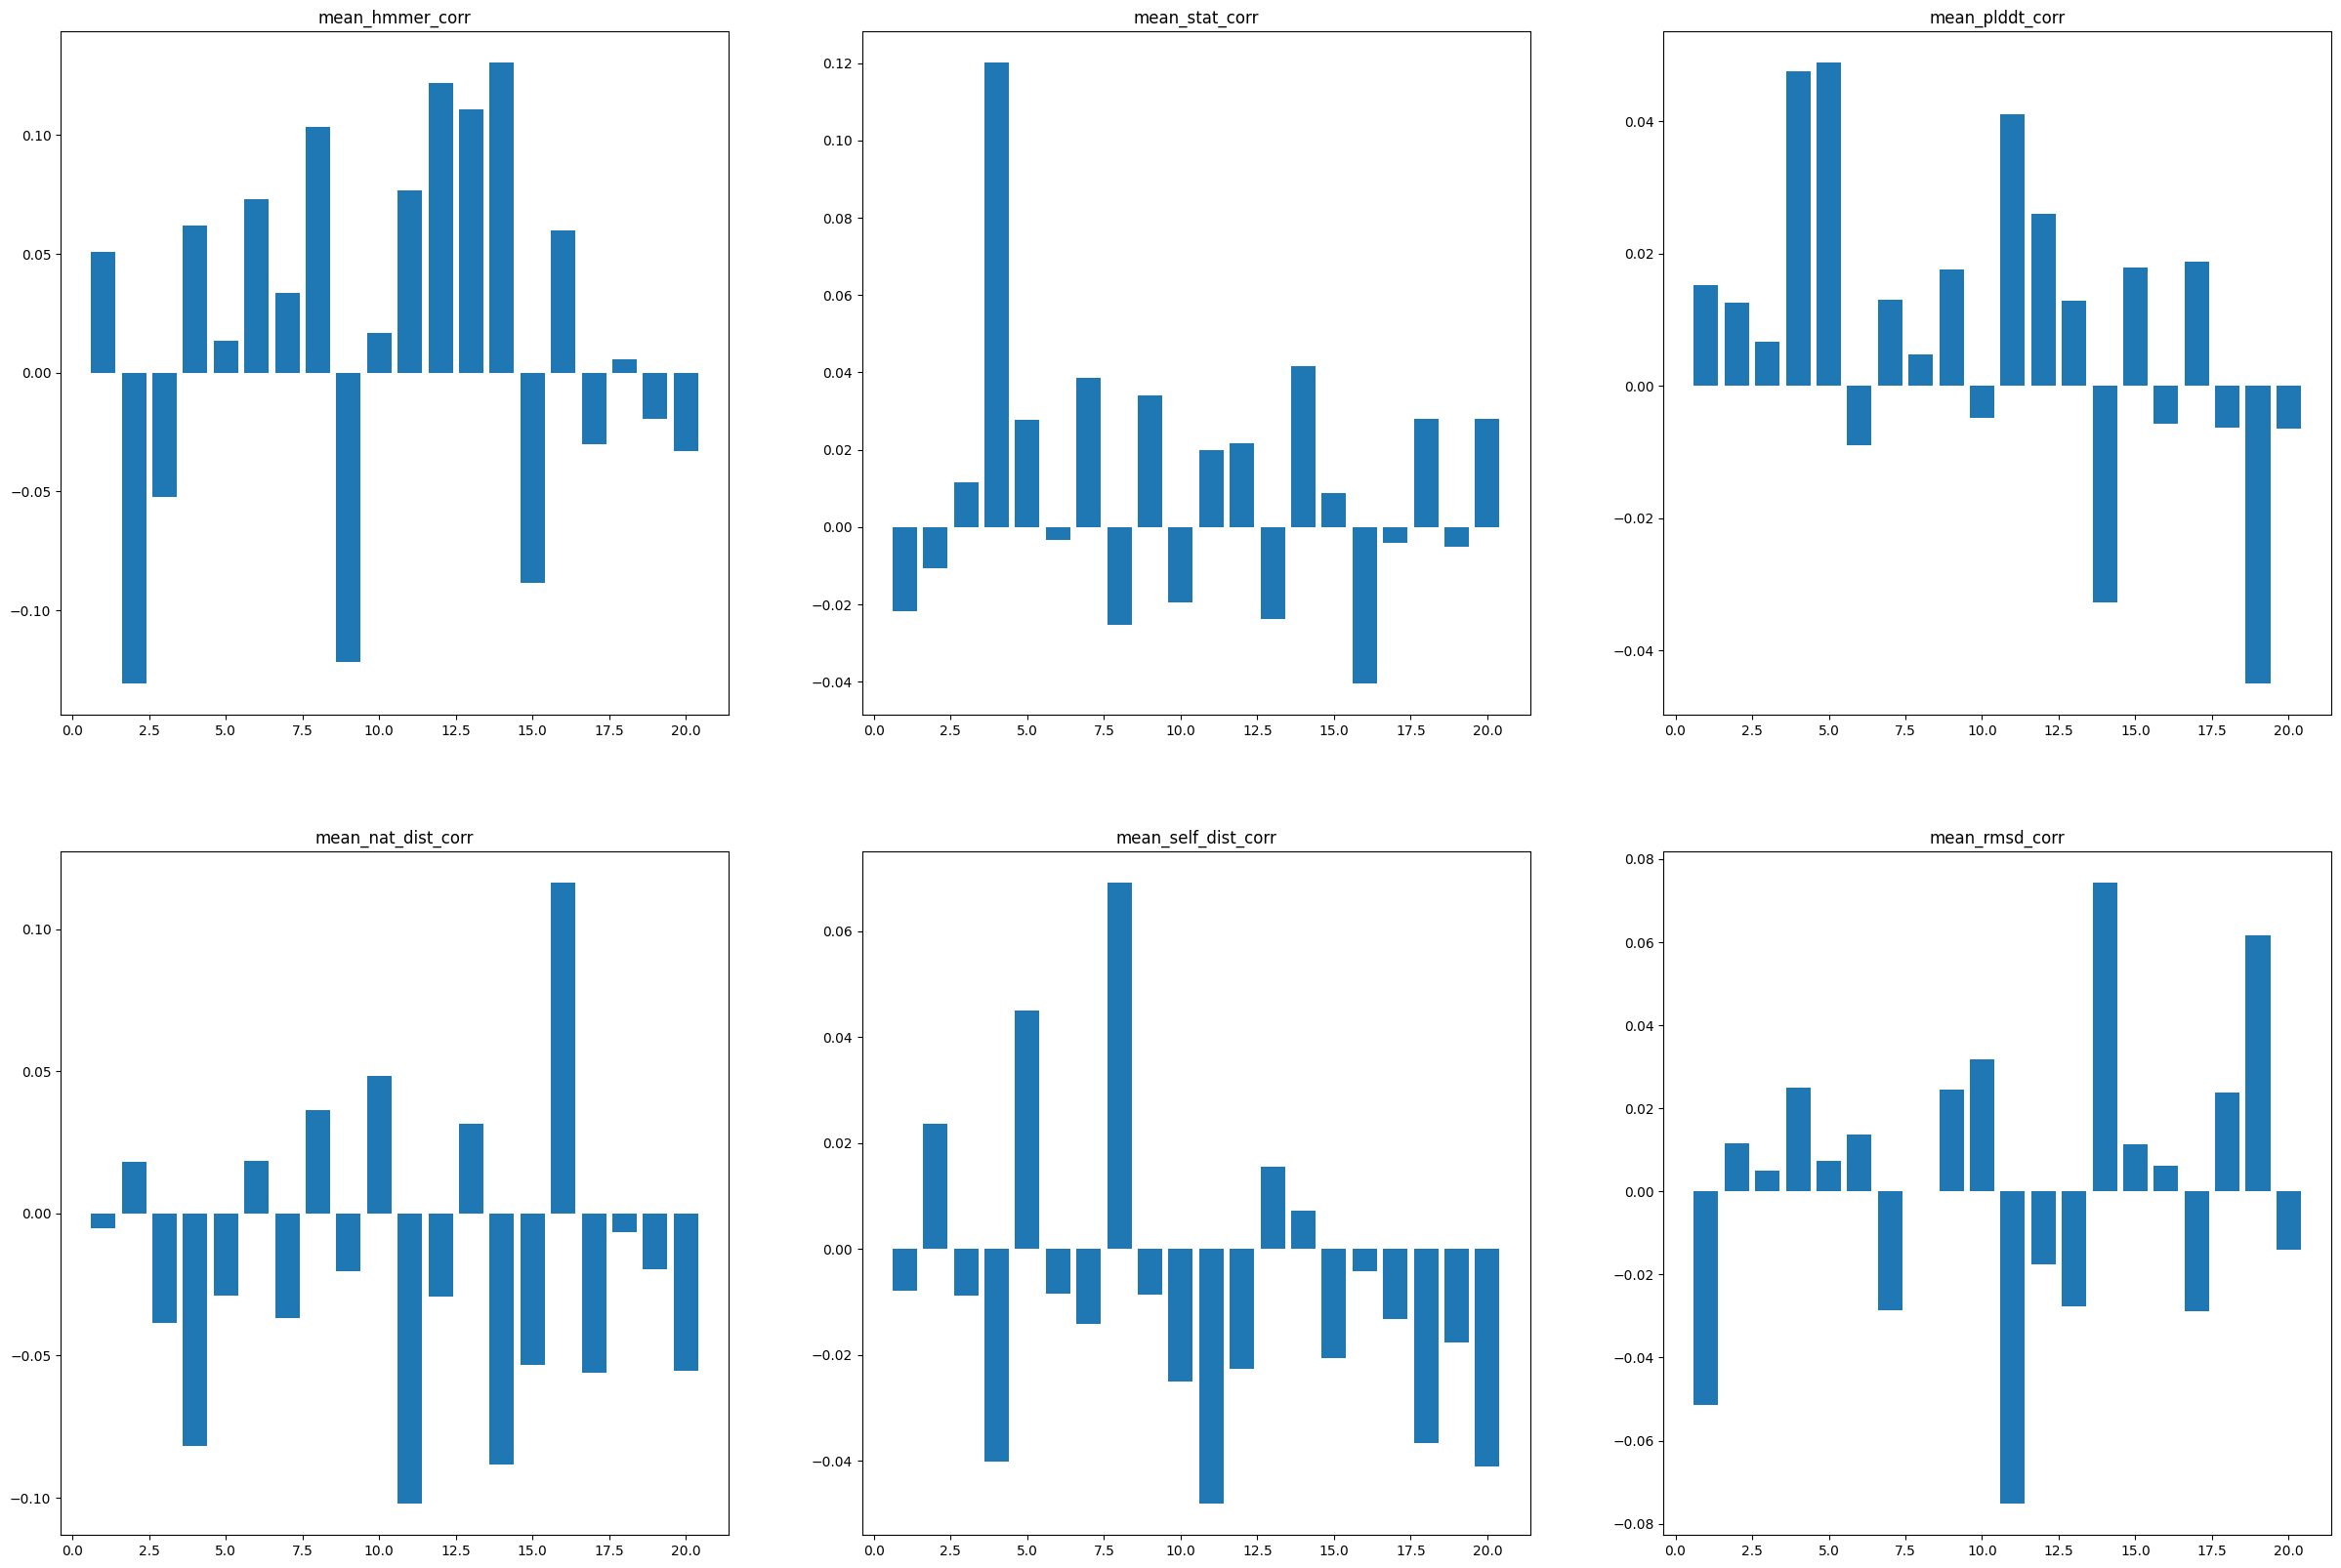

In [44]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (30,20))

axes[0][0].bar(x = range(1,21), height = mean_hmmer_corr)
axes[0][0].set_title(f"mean_hmmer_corr")

axes[0][1].bar(x = range(1,21), height = mean_stat_corr)
axes[0][1].set_title(f"mean_stat_corr")

axes[0][2].bar(x = range(1,21), height = mean_plddt_corr)
axes[0][2].set_title(f"mean_plddt_corr")

axes[1][0].bar(x = range(1,21), height = mean_nat_dist_corr)
axes[1][0].set_title(f"mean_nat_dist_corr")

axes[1][1].bar(x = range(1,21), height = mean_self_dist_corr)
axes[1][1].set_title(f"mean_self_dist_corr")

axes[1][2].bar(x = range(1,21), height = mean_rmsd_corr)
axes[1][2].set_title(f"mean_rmsd_corr")

In [4]:
import torch
import esm

sequence = "MRKDFVANVSHELKTPITSIKGFTETLLDGMEDKEALSEFLSIILKESERLQSLVQDLLDLSKIEQ"

model = esm.pretrained.esmfold_v1()
model = model.eval().cuda()

with torch.no_grad():
        pdb_file = model.infer_pdb(sequence)

with open("nat_PF00512.pdb", "w") as f:
    f.write(pdb_file)

In [2]:
from Bio import SeqIO
from scripts.aux_msa_functions import *
import subprocess

nat_seed_sequences = [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse("./data/protein-families-msa-seed/PF00004_seed.fasta", "fasta")]

array_MSA = np.array([list(sequence[1]) for sequence in nat_seed_sequences])
len_MSA = array_MSA.shape[1]
n_seqs = array_MSA.shape[0] 

bootstrap_MSA =  np.empty_like(array_MSA)
column_sample_inds = np.random.choice(range(len_MSA), len_MSA, replace=True)

bootstrap_MSA = array_MSA[:,column_sample_inds]
bootstrap_MSA = [(f'seq{i}', ''.join(bootstrap_MSA[i])) for i in range(n_seqs)]

bootstrap_MSA_path = "bootstrap_tree.fasta"

Seq_tuples_to_fasta(bootstrap_MSA, bootstrap_MSA_path)

In [6]:
column_sample_inds

array([ 52, 110, 120,  98, 110, 130, 111, 113,  55,   7,  87,  30,   8,
        84,  77,  16, 116,   2,  75,  96,  66, 112,   8,  85,  96, 126,
       116,  53,  52,   5, 105,  94,  42,  51,  11,  17, 104,   6,  90,
        38,  96,  14,  16,  87,   4,  11,   2,  83,  85,  17,  77,  60,
        23,  17,  39, 102,  51, 111,  19,  16,  81,  93,  50,  89,  26,
        97, 115,  34, 115,  19,  89,  48, 111, 105,  56,  77,   2, 104,
        13,  76,  52, 129, 101, 128,  29,  14, 124,  55,  23,  12,  21,
         9,  20,  55,  81,  63, 118, 102, 104,  58,  54,  26,  56,  56,
        62,  23,  38,  90,   5,  43, 112,  21,  25,  97,  21,  92,  31,
        47, 109,  86,  21,  25,  82,   1, 120,  44,  91,   8,  96,   6,
        49,  37])